In [1]:
import logging
from tmu.models.classification.vanilla_classifier import TMClassifier
import os
import config
import pickle
import numpy as np
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_canny_edge_detection_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-10 21:16:38,905 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-05-10 21:16:38,912 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-05-10 21:16:38,995 - matplotlib - DEBUG - interactive is False
2026-05-10 21:16:38,996 - matplotlib - DEBUG - platform is linux
2026-05-10 21:16:39,089 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-05-10 21:16:39,092 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.CANNY
CURRENT_DATASET = config.BLOODMNIST
CURRENT_RESOLUTION = 1 
specialist_name = "Canny Edge"
channel_names = [f"{specialist_name} - {c}" for c in ["Red", "Green", "Blue"]]


In [3]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [4]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_canny_edge_detection_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

In [5]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)
Y_val = Y_val.astype(np.uint32)

In [ ]:
study = run_tm_optuna_search(
    TMClassifier,
    config,
    X_train,
    Y_train,
    X_val,
    Y_val,
    metric="f1_macro",  
)

[I 2026-03-14 19:33:19,122] A new study created in memory with name: no-name-e1220f7f-9139-4254-b88e-727c6f9b7c3a


[I 2026-03-14 22:13:25,811] Trial 0 finished with value: 0.7209468329739777 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7209468329739777.


[I 2026-03-15 00:51:49,653] Trial 1 finished with value: 0.6835028317459078 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7209468329739777.


[I 2026-03-15 04:00:17,913] Trial 2 finished with value: 0.7380287944900228 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.7380287944900228.


[I 2026-03-15 06:56:39,032] Trial 3 finished with value: 0.7437666264464038 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 3 with value: 0.7437666264464038.


...

[I 2026-03-20 03:08:03,266] Trial 46 finished with value: 0.7143017614792648 and parameters: {'s': 11.0, 'T': 6000, 'patch_size': 3, 'max_included_literals': 32}. Best is trial 24 with value: 0.7789302899339092.


[I 2026-03-20 05:44:48,972] Trial 47 finished with value: 0.7644036999456747 and parameters: {'s': 14.0, 'T': 7500, 'patch_size': 7, 'max_included_literals': 32}. Best is trial 24 with value: 0.7789302899339092.


[I 2026-03-20 08:15:45,410] Trial 48 finished with value: 0.7485852856668758 and parameters: {'s': 5.0, 'T': 8000, 'patch_size': 7, 'max_included_literals': 32}. Best is trial 24 with value: 0.7789302899339092.


[I 2026-03-20 10:34:36,633] Trial 49 finished with value: 0.7545423972353639 and parameters: {'s': 9.0, 'T': 5000, 'patch_size': 5, 'max_included_literals': 512}. Best is trial 24 with value: 0.7789302899339092.


Best f1_macro: 0.7789302899339092
Best hyperparameters: {'s': 6.0, 'T': 9000, 'patch_size': 7, 'max_included_literals': 32}


In [ ]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/canny_edge.json")

Best F1 score macro accuracy: 0.7789302899339092
Best hyperparameters: {'s': 6.0, 'T': 9000, 'patch_size': 7, 'max_included_literals': 32}
Best Optuna results saved to hyperparameters/canny_edge.json


In [6]:
best_value, best_params = load_optuna_best_results("hyperparameters/canny_edge.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [ ]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BloodMNIST_Canny",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 66.50% (416.83s)


#2 Accuracy: 69.83% (381.12s)


#3 Accuracy: 71.44% (365.76s)


#4 Accuracy: 75.88% (359.70s)


...

#96 Accuracy: 78.31% (300.29s)


#97 Accuracy: 80.15% (299.86s)


#98 Accuracy: 79.98% (300.09s)


#99 Accuracy: 79.68% (300.18s)


#100 Accuracy: 79.95% (299.14s)


In [7]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BloodMNIST_Canny_Specialist.pkl")

In [ ]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [8]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

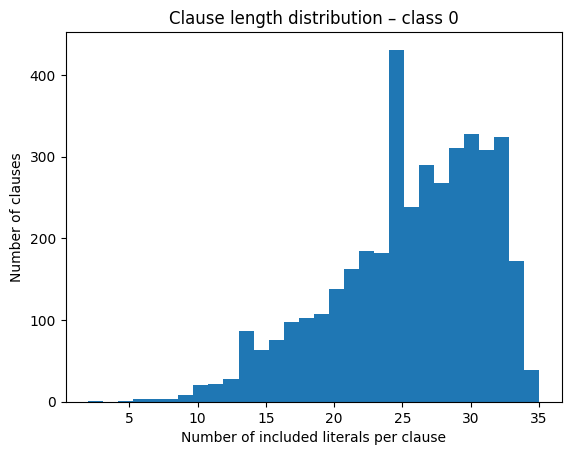

Class 0: median=27.0, mean=25.5, std=5.6


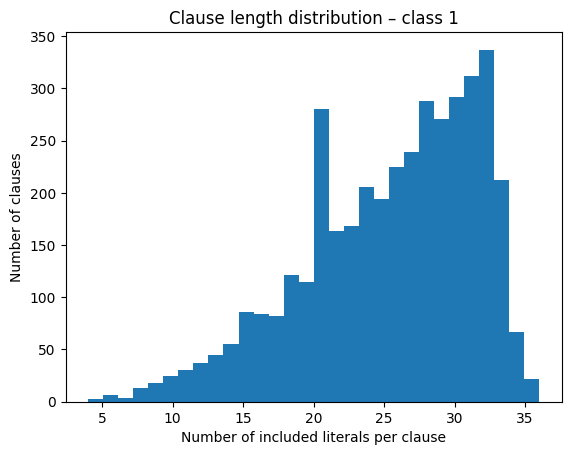

Class 1: median=27.0, mean=25.4, std=6.1


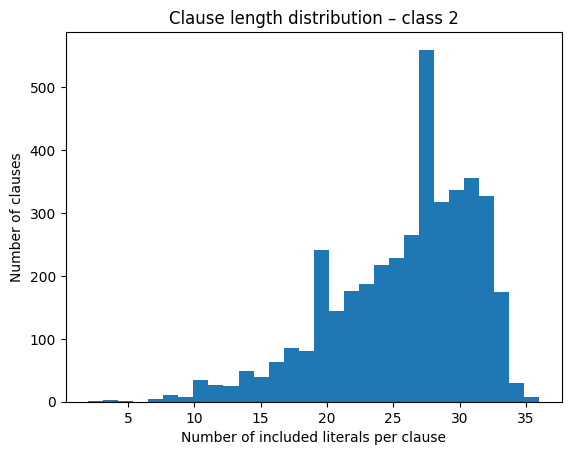

Class 2: median=27.0, mean=25.9, std=5.4


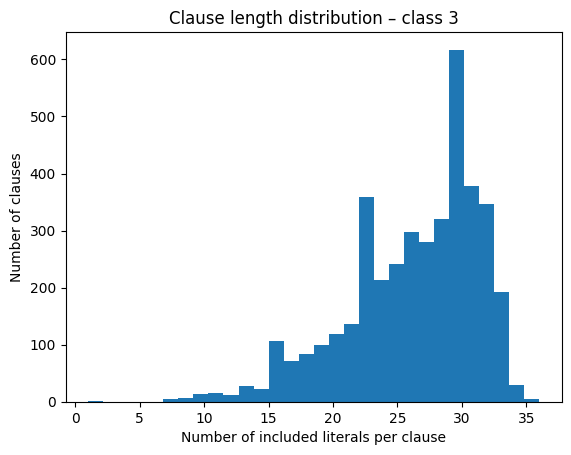

Class 3: median=27.0, mean=26.2, std=5.1


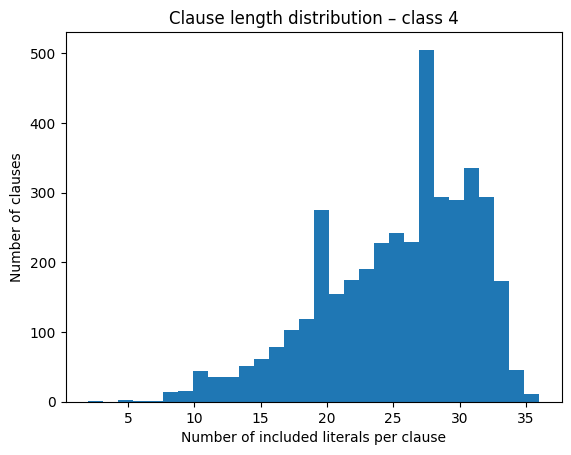

Class 4: median=26.0, mean=25.3, std=5.7


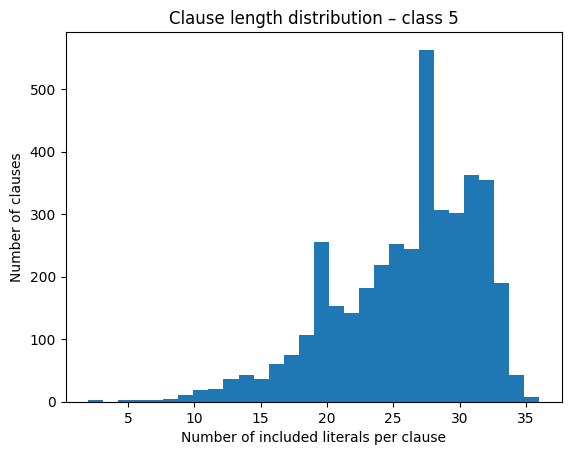

Class 5: median=27.0, mean=26.0, std=5.4


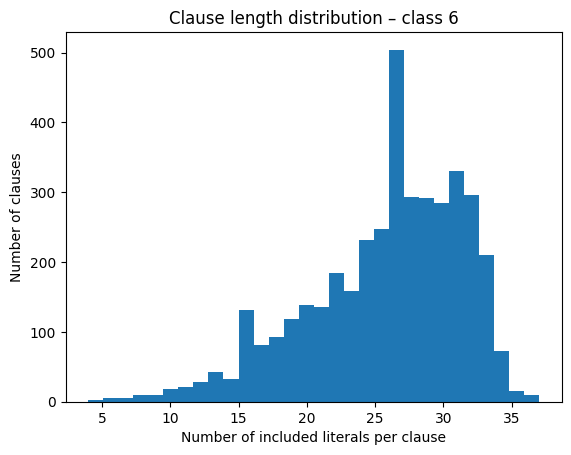

Class 6: median=27.0, mean=25.7, std=5.7


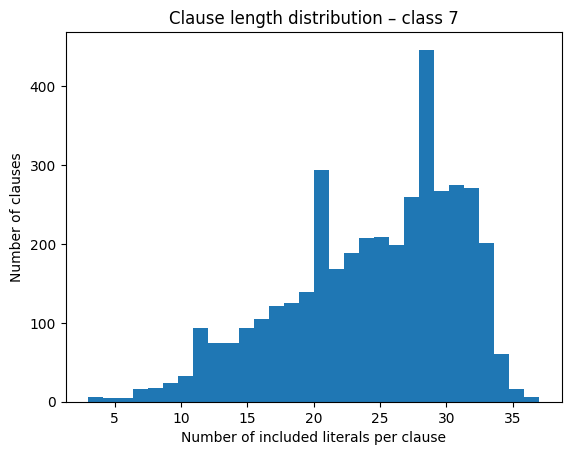

Class 7: median=26.0, mean=24.5, std=6.5


In [ ]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 79.95%
2026-05-10 21:17:46,408 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x778f1a328920>


Saved to saved_confusion_matrices/blood_canny.svg


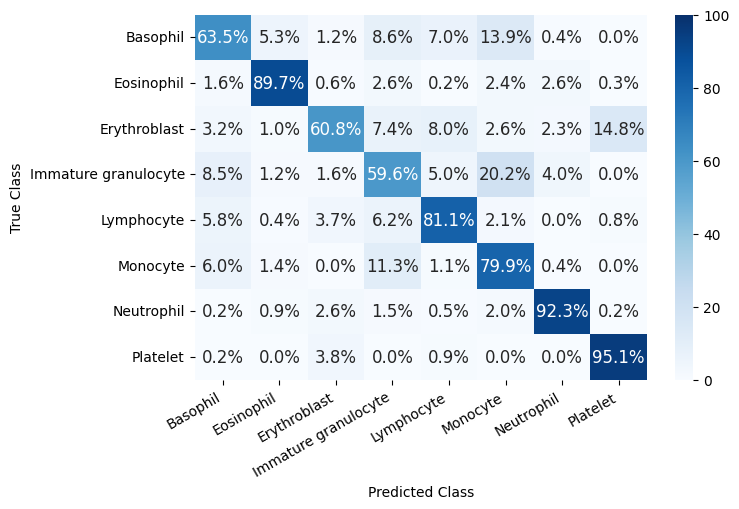

In [15]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="BloodMNIST_Canny", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, rotate_xlabels=True, figsize=(7.8, 5.2)) 

# Class 0 Local Examples 

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

0
2026-04-15 11:34:53,463 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-15 11:34:53,466 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 302  |  predicted class: 0
2026-04-15 11:34:53,495 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e2410c8c500>
Saved to saved_heatmaps/canny/blood_canny_lh_c0_s302_aggr.svg


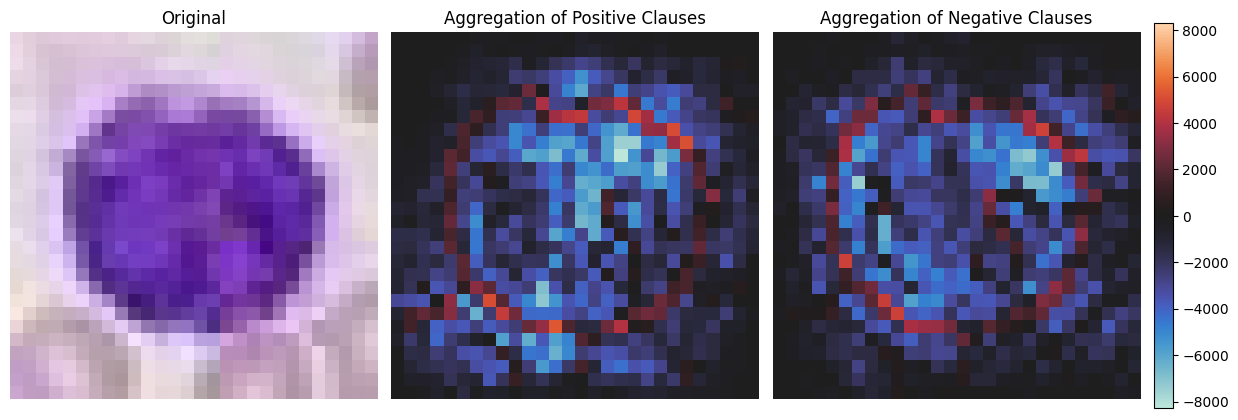

Visualizing sample 302  |  predicted class: 0
2026-04-15 11:34:57,635 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e23ecd1bf80>
2026-04-15 11:34:57,661 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e23f2d02ed0>
2026-04-15 11:34:57,688 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7e23f2cdde50>
Saved to saved_heatmaps/canny/blood_canny_lh_c0_s302_chan.svg


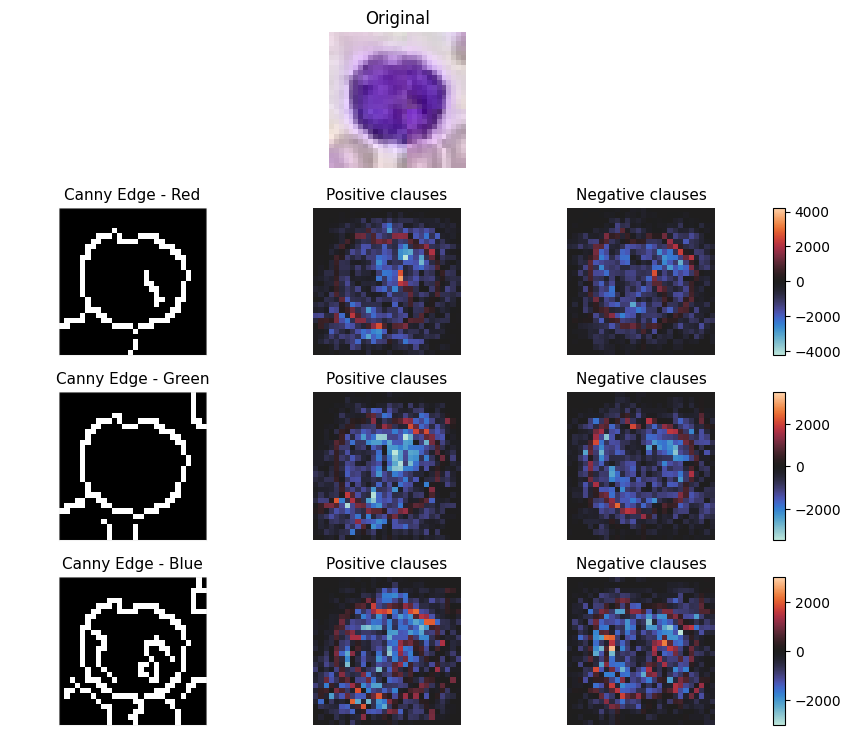

In [ ]:
image_index =  302
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

0
Visualizing sample 2281  |  predicted class: 0
2026-04-10 15:45:27,437 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9db04d0>
Saved to saved_heatmaps/canny/blood_canny_lh_c0_s2281_aggr.svg


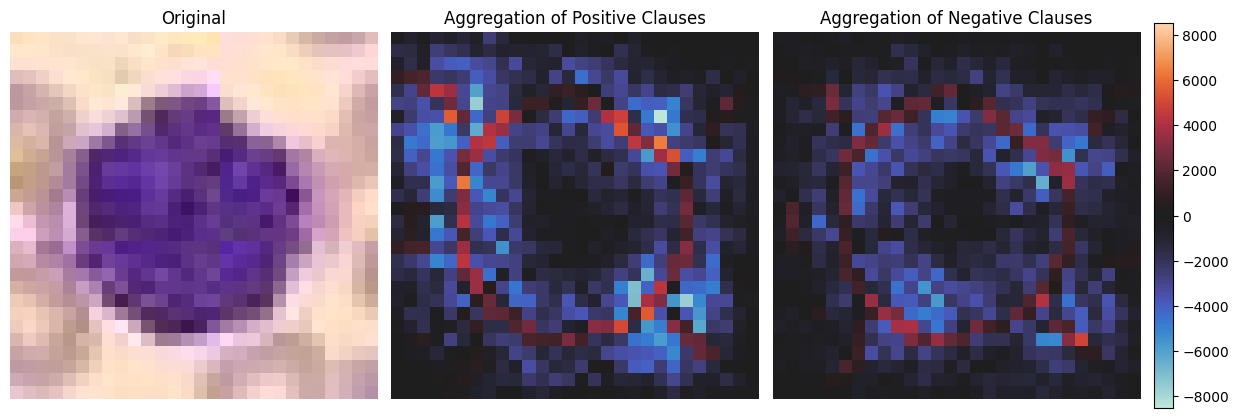

Visualizing sample 2281  |  predicted class: 0
2026-04-10 15:45:31,334 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9b8fe90>
2026-04-10 15:45:31,363 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9a652b0>
2026-04-10 15:45:31,391 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9b0ee40>
Saved to saved_heatmaps/canny/blood_canny_lh_c0_s2281_chan.svg


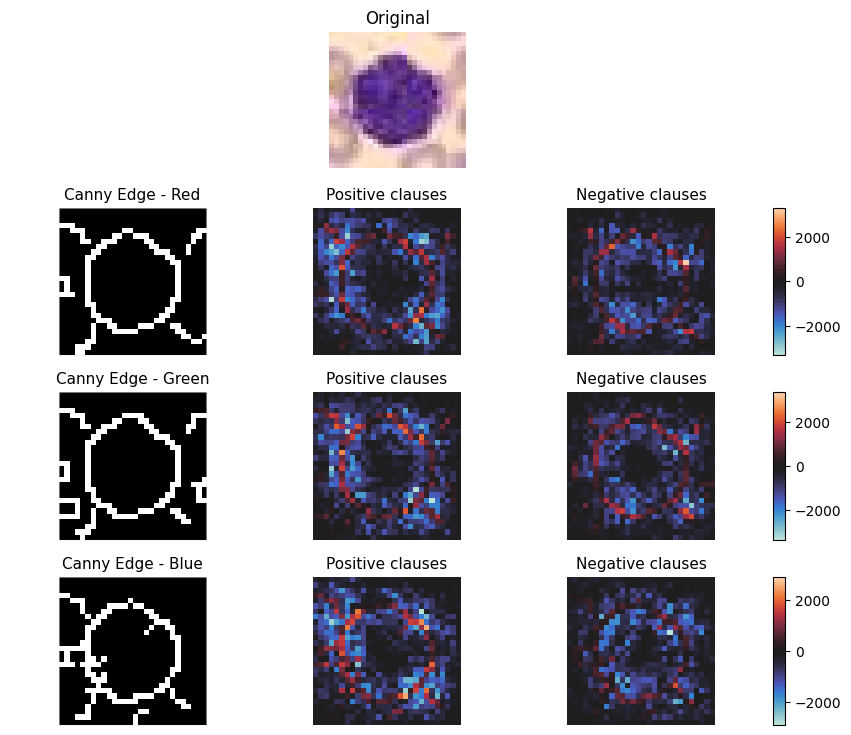

In [ ]:
image_index =  2281
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

0
Visualizing sample 2587  |  predicted class: 0
2026-04-10 15:45:35,595 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac4112ea0>
Saved to saved_heatmaps/canny/blood_canny_lh_c0_s2587_aggr.svg


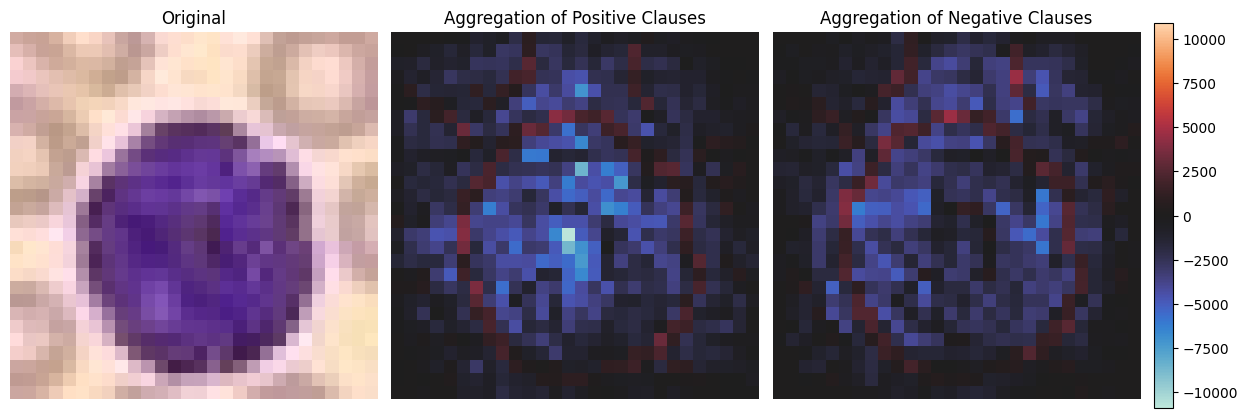

Visualizing sample 2587  |  predicted class: 0
2026-04-10 15:45:39,620 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6b78380>
2026-04-10 15:45:39,809 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac41bfcb0>
2026-04-10 15:45:39,836 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac41a1fd0>
Saved to saved_heatmaps/canny/blood_canny_lh_c0_s2587_chan.svg


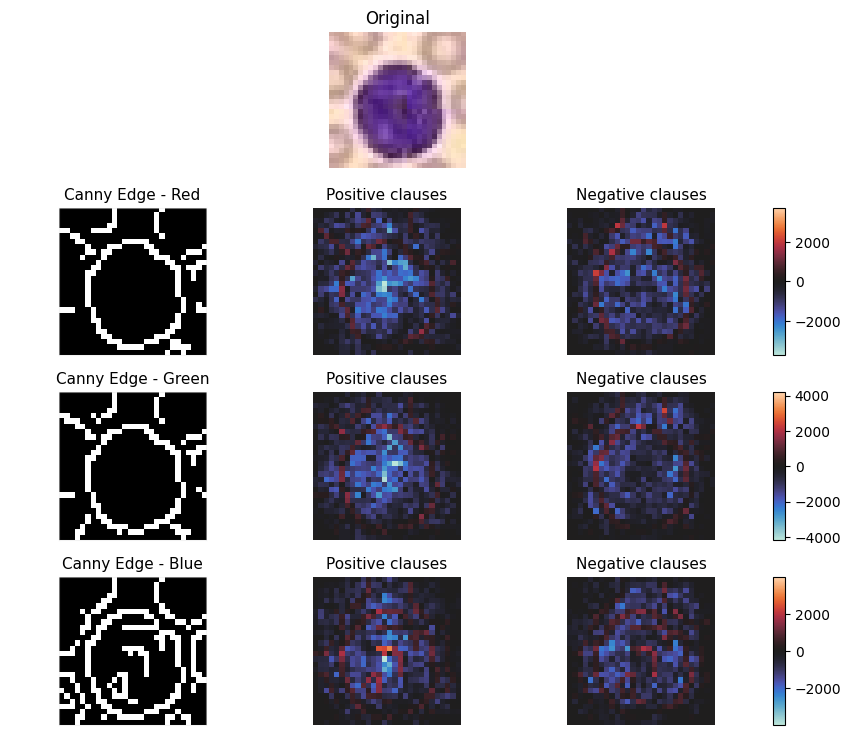

In [ ]:
image_index =  2587
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 1 Local Examples

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

1
Visualizing sample 138  |  predicted class: 1
2026-04-10 15:45:44,074 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac4142810>
Saved to saved_heatmaps/canny/blood_canny_lh_c1_s138_aggr.svg


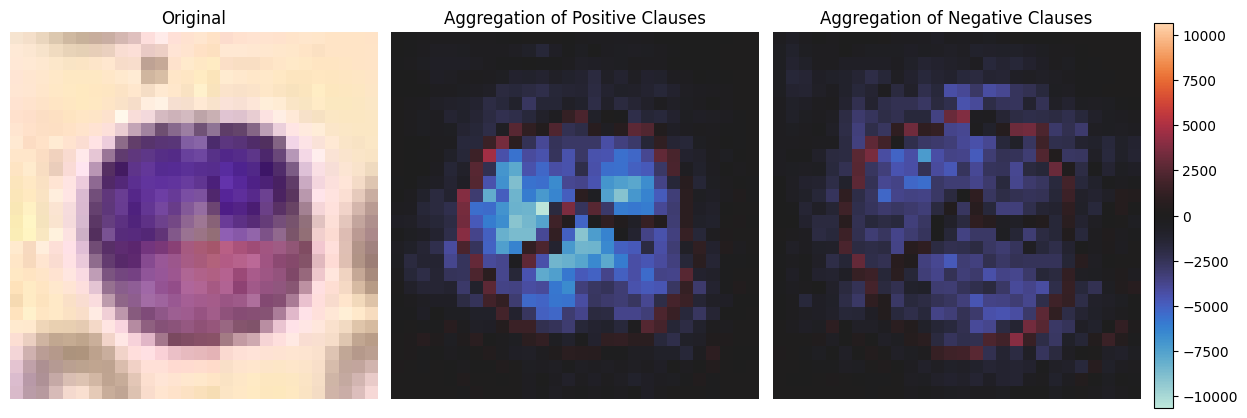

Visualizing sample 138  |  predicted class: 1
2026-04-10 15:45:48,054 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9d054c0>
2026-04-10 15:45:48,082 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9db0f50>
2026-04-10 15:45:48,110 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aea07aff0>
Saved to saved_heatmaps/canny/blood_canny_lh_c1_s138_chan.svg


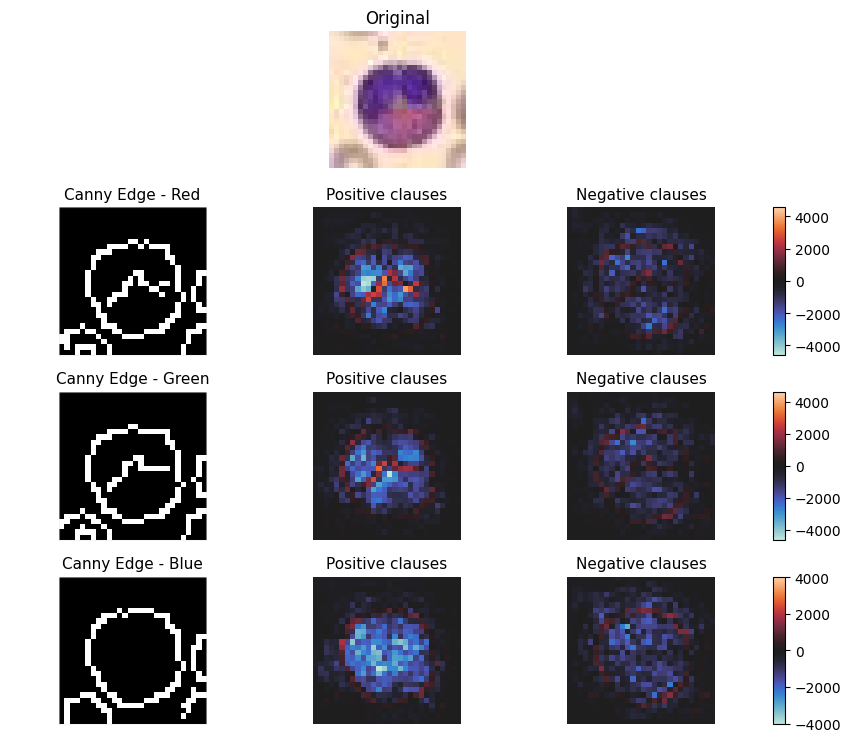

In [ ]:
image_index =  138
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

1
Visualizing sample 1920  |  predicted class: 1
2026-04-10 15:45:52,238 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ad5edb140>
Saved to saved_heatmaps/canny/blood_canny_lh_c1_s1920_aggr.svg


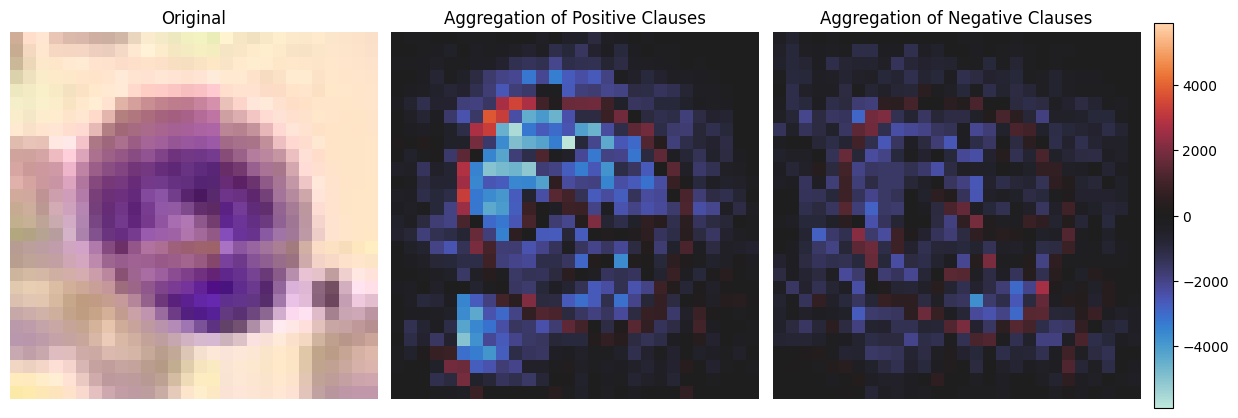

Visualizing sample 1920  |  predicted class: 1
2026-04-10 15:45:55,964 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca0ebce0>
2026-04-10 15:45:55,992 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9abf140>
2026-04-10 15:45:56,183 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ad066a990>
Saved to saved_heatmaps/canny/blood_canny_lh_c1_s1920_chan.svg


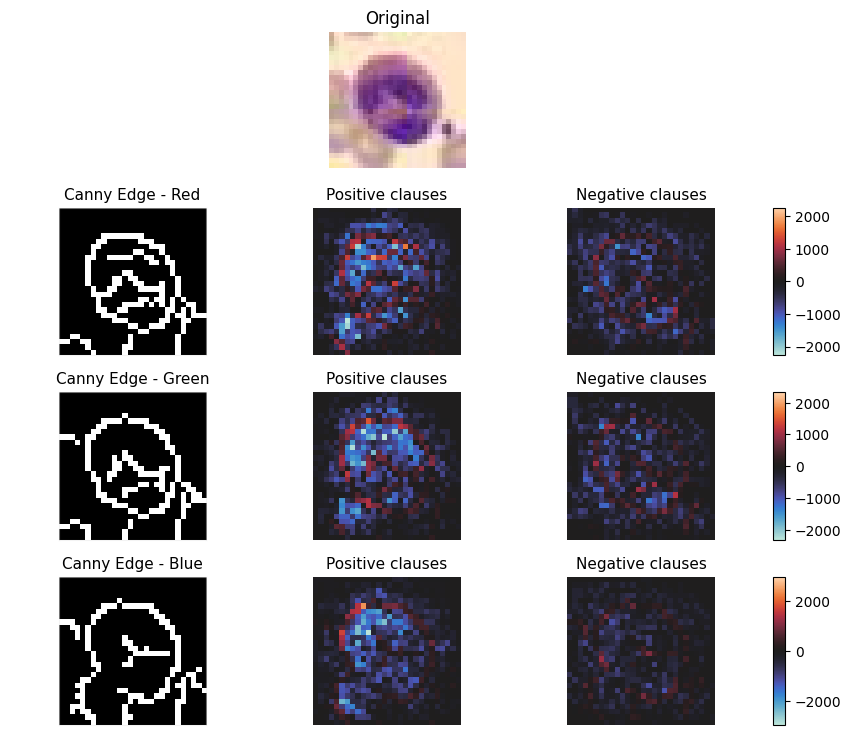

In [ ]:
image_index =  1920
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

1
Visualizing sample 352  |  predicted class: 1
2026-04-10 15:46:00,368 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac40f8d10>
Saved to saved_heatmaps/canny/blood_canny_lh_c1_s352_aggr.svg


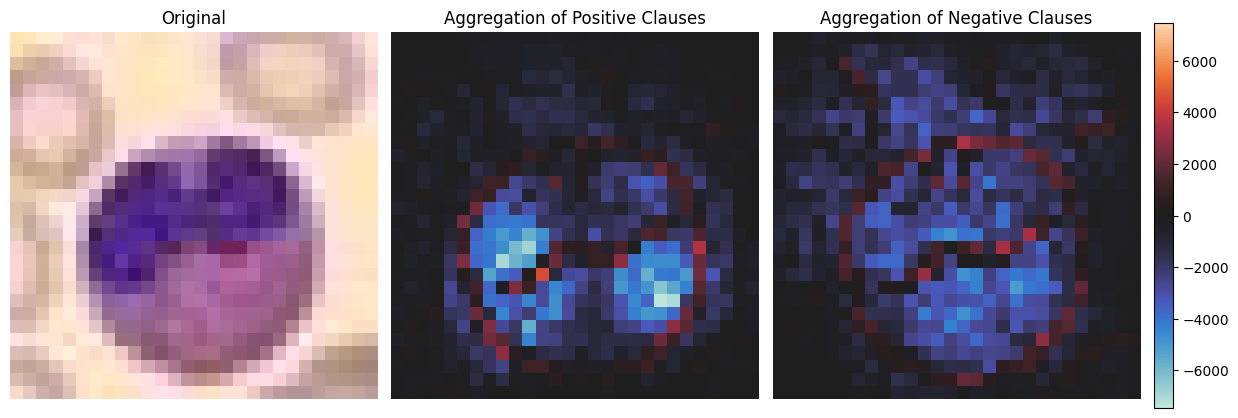

Visualizing sample 352  |  predicted class: 1
2026-04-10 15:46:04,277 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6affbc0>
2026-04-10 15:46:04,304 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0eb7350>
2026-04-10 15:46:04,330 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9a64bc0>
Saved to saved_heatmaps/canny/blood_canny_lh_c1_s352_chan.svg


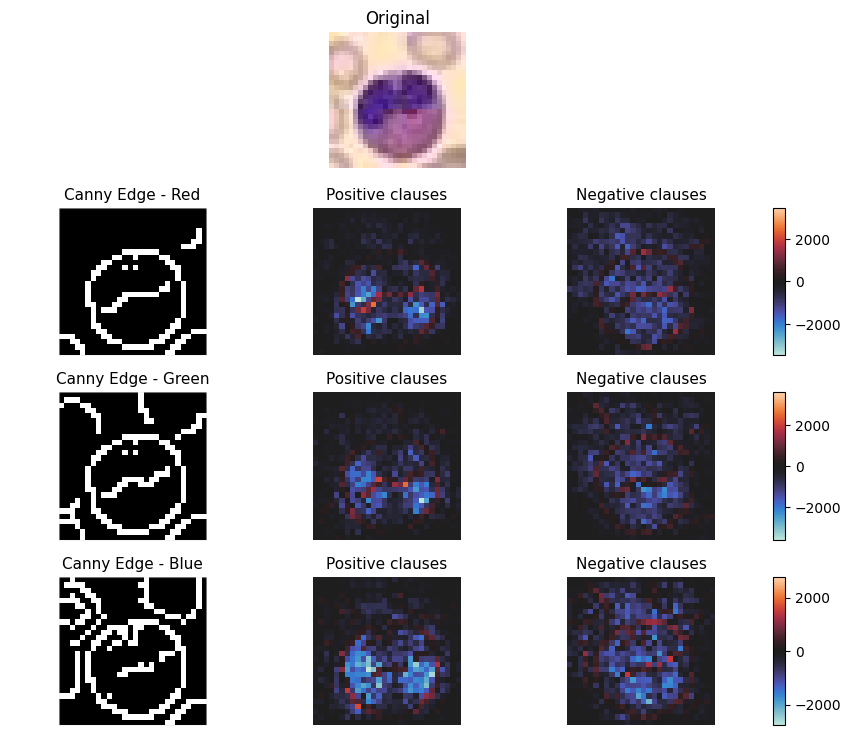

In [ ]:
image_index =  352
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 2 Local Examples

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=2, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

2


Visualizing sample 100  |  predicted class: 2
2026-04-10 15:46:08,538 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9c9b800>
Saved to saved_heatmaps/canny/blood_canny_lh_c2_s100_aggr.svg


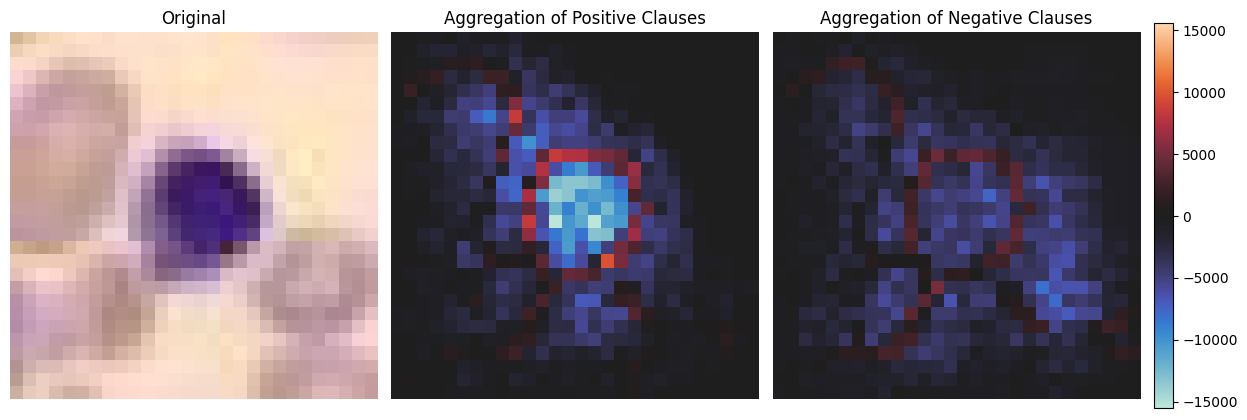

Visualizing sample 100  |  predicted class: 2
2026-04-10 15:46:12,497 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9d040e0>
2026-04-10 15:46:12,524 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9b8ef30>
2026-04-10 15:46:12,550 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0f64dd0>
Saved to saved_heatmaps/canny/blood_canny_lh_c2_s100_chan.svg


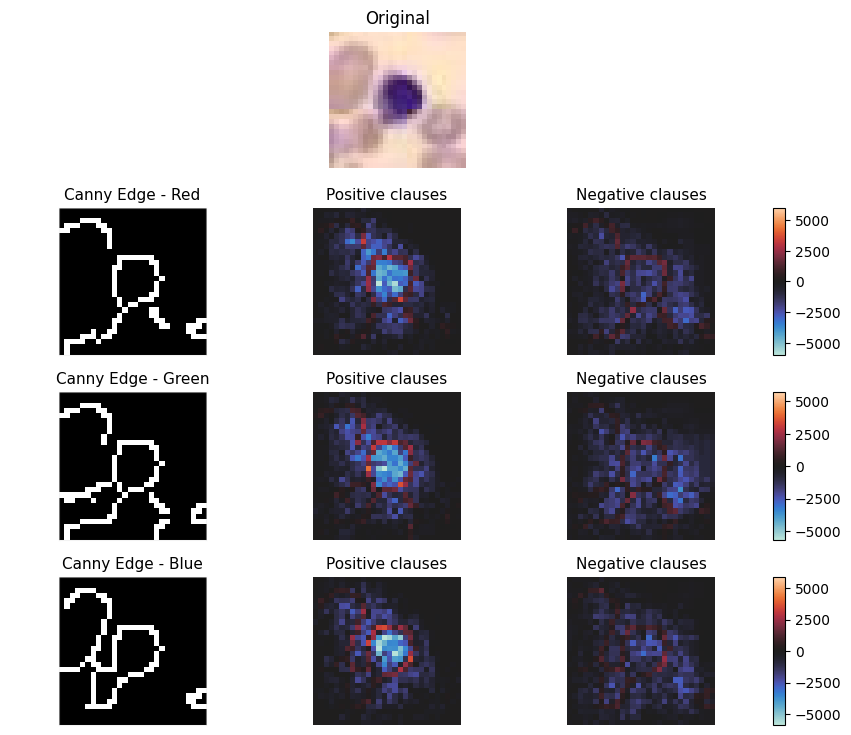

In [ ]:
image_index =  100
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

2


Visualizing sample 1810  |  predicted class: 2
2026-04-10 15:46:17,766 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0ed8b00>
Saved to saved_heatmaps/canny/blood_canny_lh_c2_s1810_aggr.svg


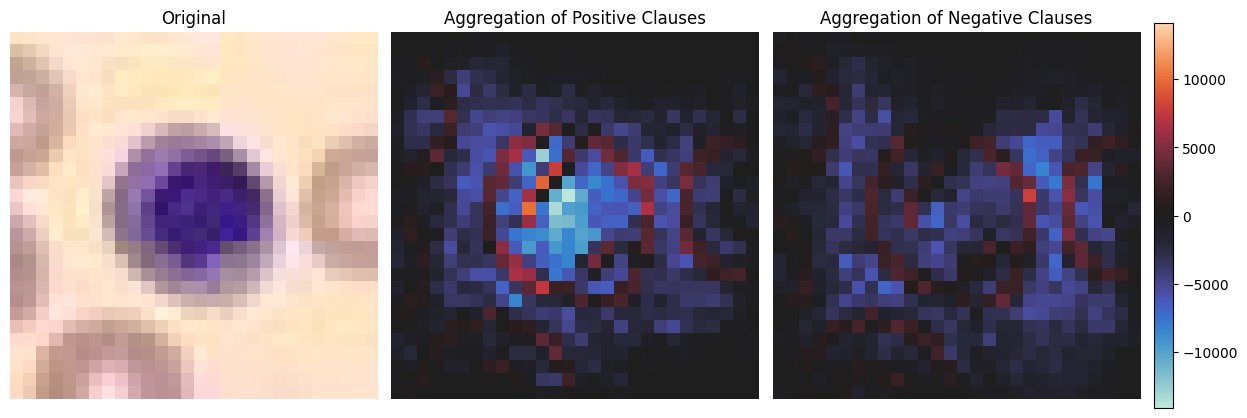

Visualizing sample 1810  |  predicted class: 2
2026-04-10 15:46:22,013 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9ae0560>
2026-04-10 15:46:22,041 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9fd41d0>
2026-04-10 15:46:22,068 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6b1a600>
Saved to saved_heatmaps/canny/blood_canny_lh_c2_s1810_chan.svg


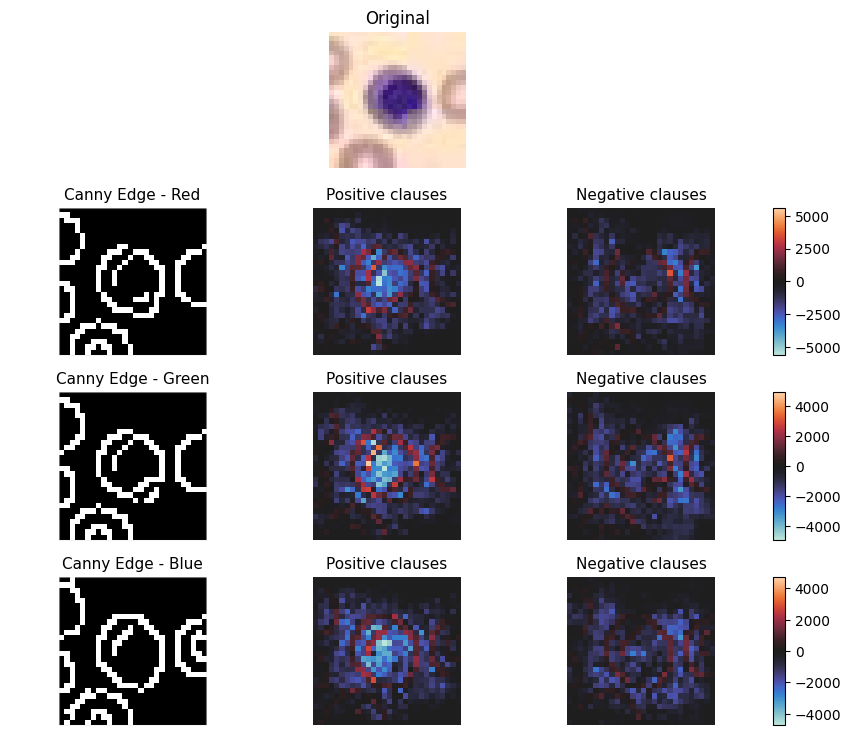

In [ ]:
image_index =  1810
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

2
Visualizing sample 865  |  predicted class: 2
2026-04-10 15:46:26,251 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6ab2030>
Saved to saved_heatmaps/canny/blood_canny_lh_c2_s865_aggr.svg


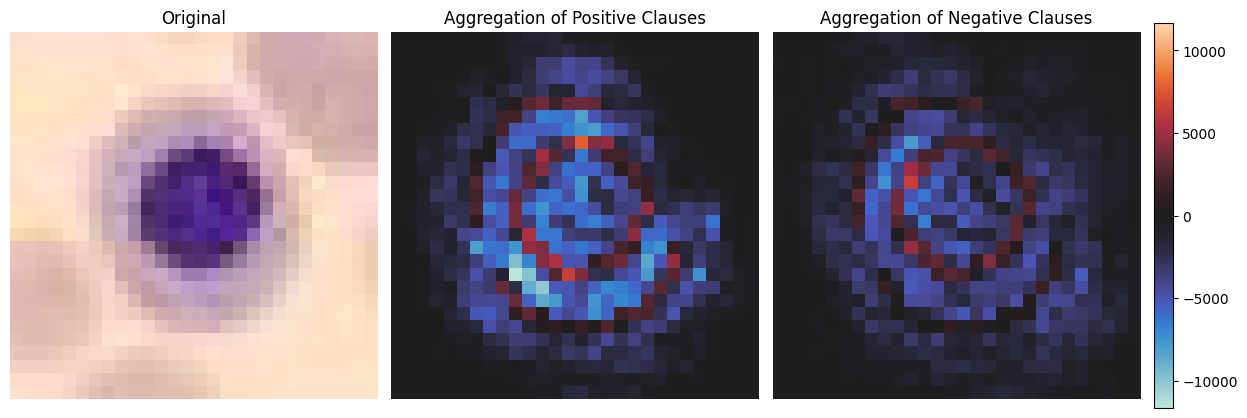

Visualizing sample 865  |  predicted class: 2
2026-04-10 15:46:30,776 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ad05f3dd0>
2026-04-10 15:46:30,808 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6b30860>
2026-04-10 15:46:30,837 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9fc5700>
Saved to saved_heatmaps/canny/blood_canny_lh_c2_s865_chan.svg


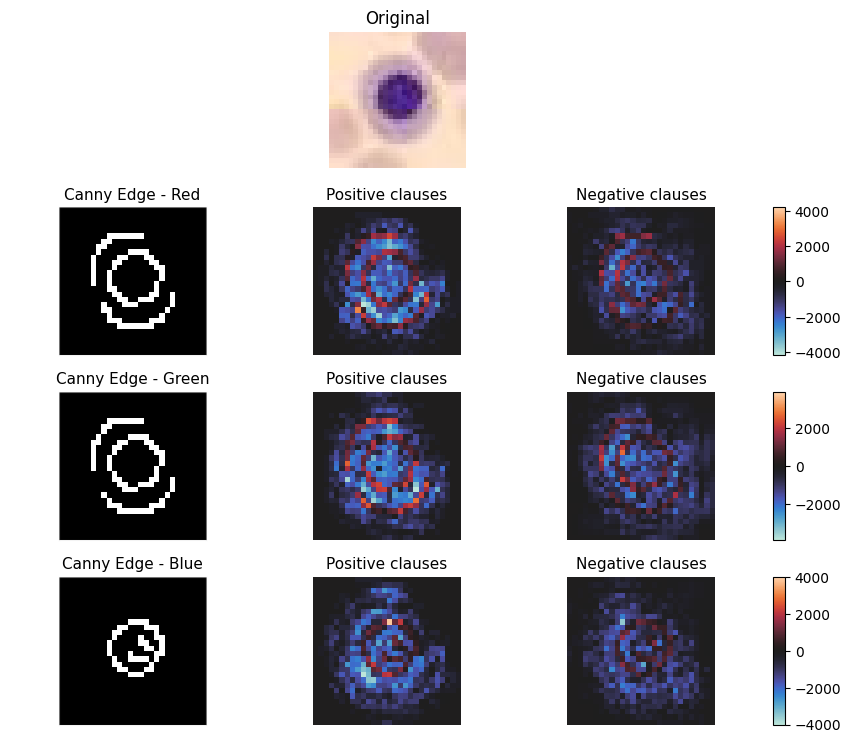

In [ ]:
image_index =  865
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 3 Local Examples

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=3, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

3
Visualizing sample 1354  |  predicted class: 3
2026-04-10 15:46:35,233 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca0d1af0>
Saved to saved_heatmaps/canny/blood_canny_lh_c3_s1354_aggr.svg


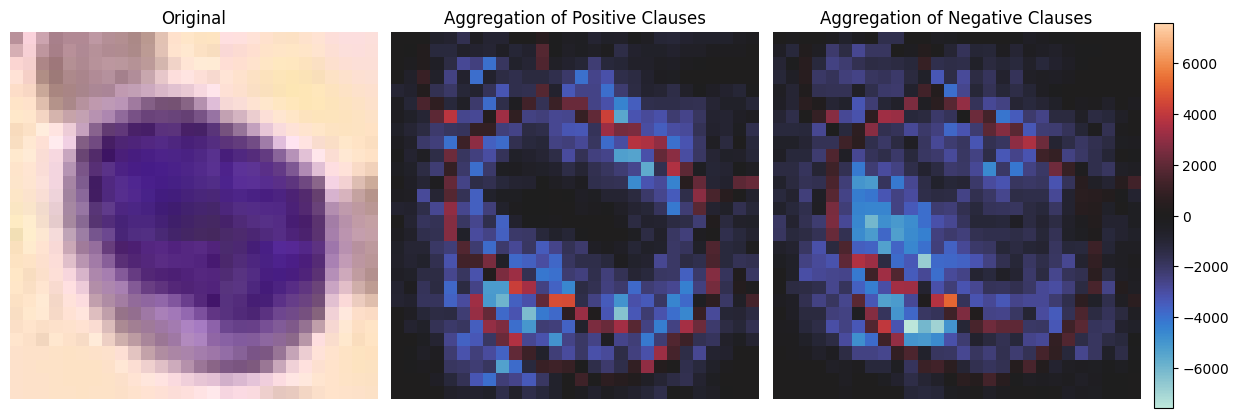

Visualizing sample 1354  |  predicted class: 3
2026-04-10 15:46:39,120 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9ed2690>
2026-04-10 15:46:39,147 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9c57cb0>
2026-04-10 15:46:39,175 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca0ba510>
Saved to saved_heatmaps/canny/blood_canny_lh_c3_s1354_chan.svg


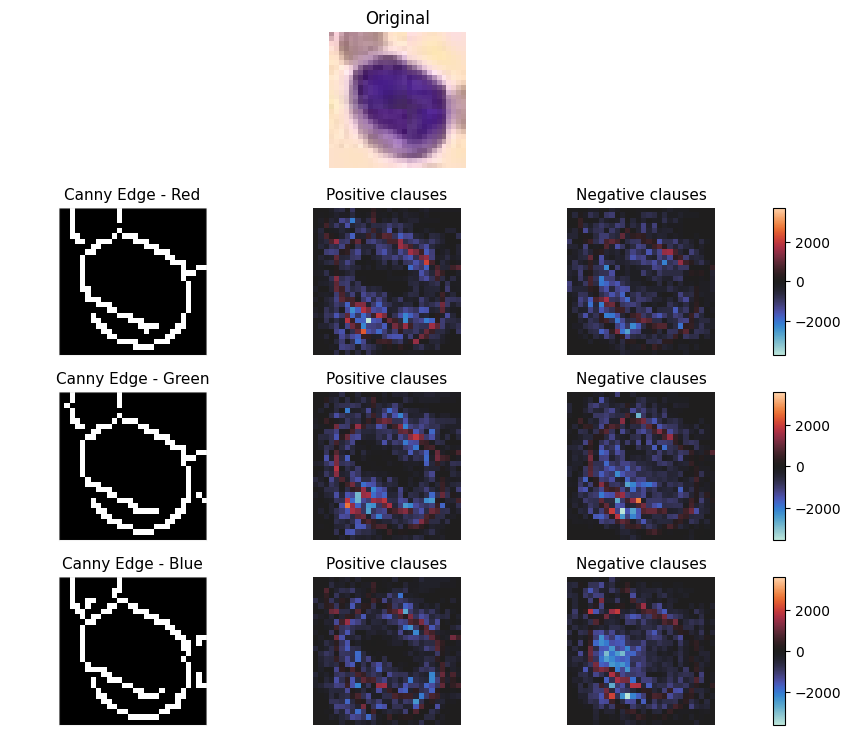

In [ ]:
image_index =  1354
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

3
Visualizing sample 558  |  predicted class: 3
2026-04-10 15:46:43,636 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9bb8cb0>
Saved to saved_heatmaps/canny/blood_canny_lh_c3_s558_aggr.svg


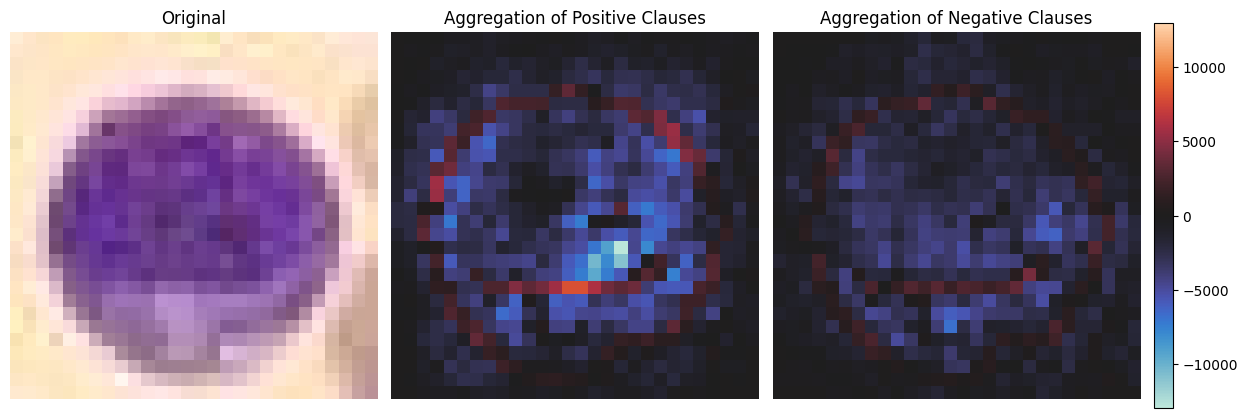

Visualizing sample 558  |  predicted class: 3
2026-04-10 15:46:48,261 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac4172150>
2026-04-10 15:46:48,288 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9b36150>
2026-04-10 15:46:48,315 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0f34da0>
Saved to saved_heatmaps/canny/blood_canny_lh_c3_s558_chan.svg


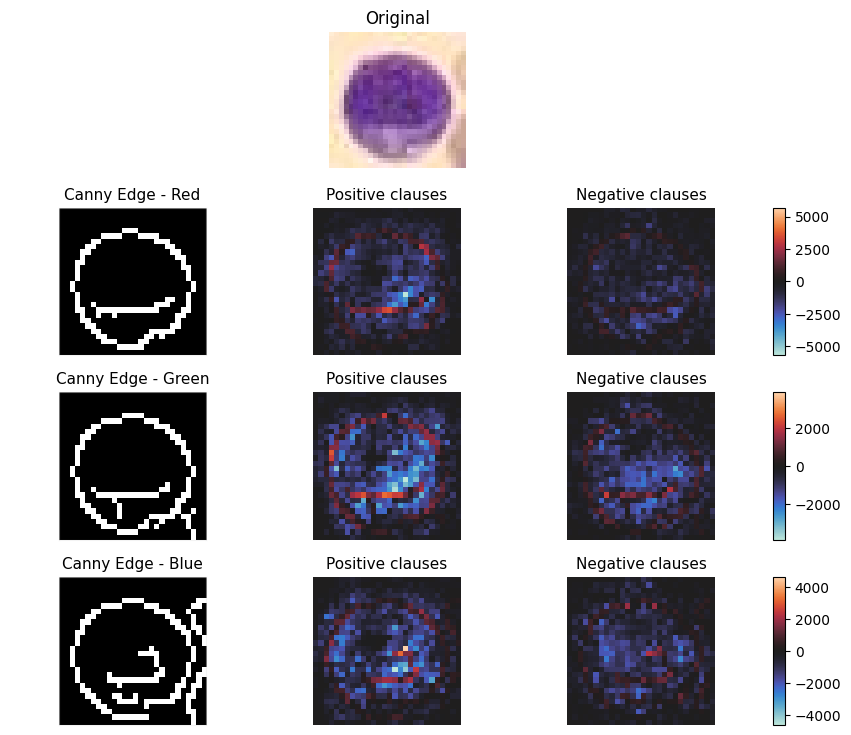

In [ ]:
image_index =  558
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

3
Visualizing sample 1223  |  predicted class: 3
2026-04-10 15:46:52,736 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0e24fe0>
Saved to saved_heatmaps/canny/blood_canny_lh_c3_s1223_aggr.svg


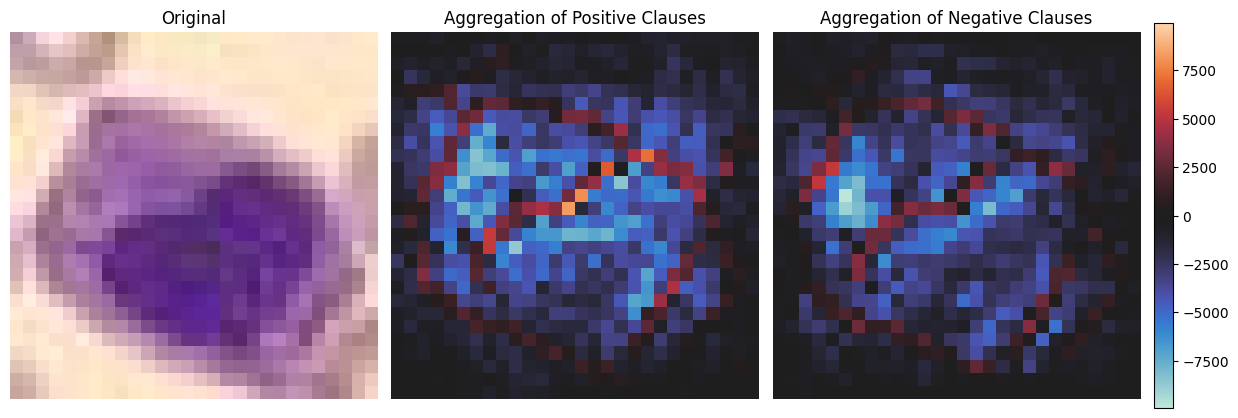

Visualizing sample 1223  |  predicted class: 3
2026-04-10 15:46:57,324 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0e26fc0>
2026-04-10 15:46:57,359 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca0eb4d0>
2026-04-10 15:46:57,386 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6b32ae0>
Saved to saved_heatmaps/canny/blood_canny_lh_c3_s1223_chan.svg


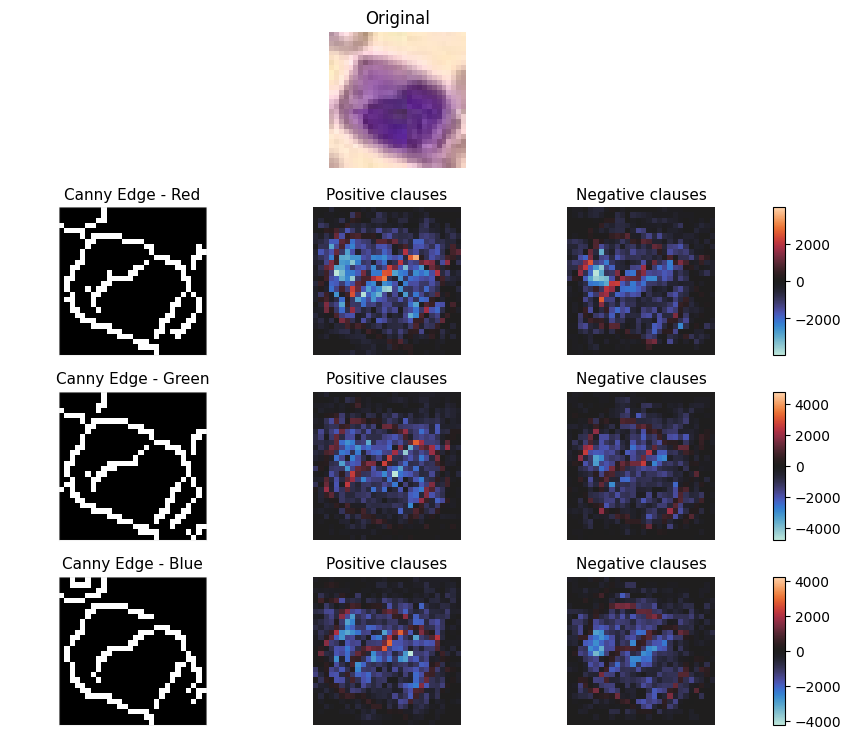

In [ ]:
image_index =  1223
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 4 Local Examples

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=4, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

4
Visualizing sample 624  |  predicted class: 4
2026-04-10 15:47:01,950 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9de3dd0>
Saved to saved_heatmaps/canny/blood_canny_lh_c4_s624_aggr.svg


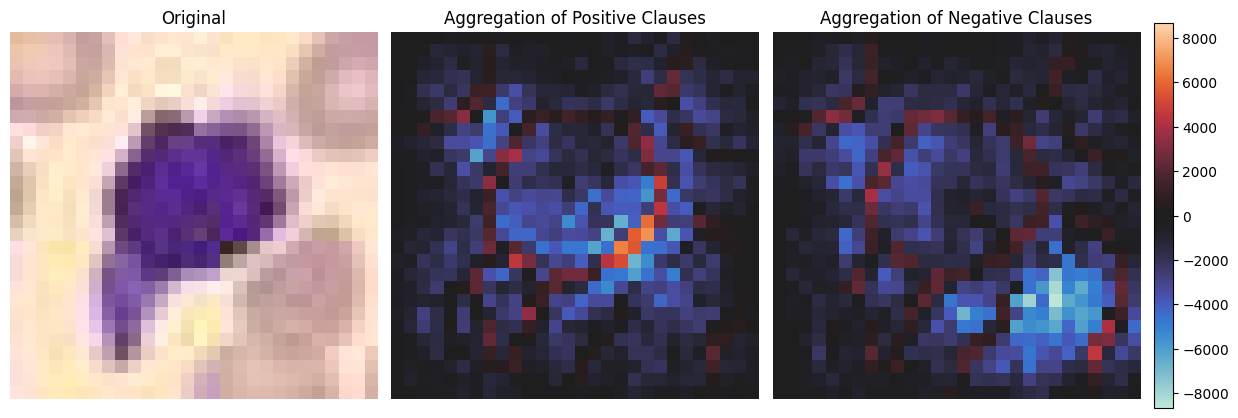

Visualizing sample 624  |  predicted class: 4
2026-04-10 15:47:05,963 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac4086a50>
2026-04-10 15:47:05,990 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9d65190>
2026-04-10 15:47:06,018 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca123980>
Saved to saved_heatmaps/canny/blood_canny_lh_c4_s624_chan.svg


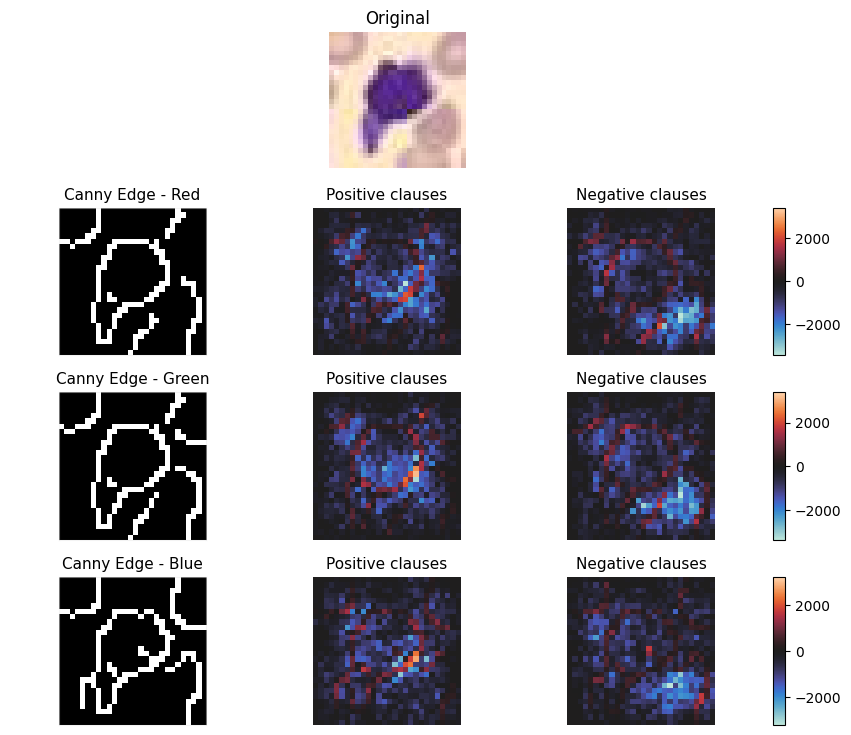

In [ ]:
image_index =  624
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

4
Visualizing sample 2046  |  predicted class: 4
2026-04-10 15:47:10,573 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9fedc10>
Saved to saved_heatmaps/canny/blood_canny_lh_c4_s2046_aggr.svg


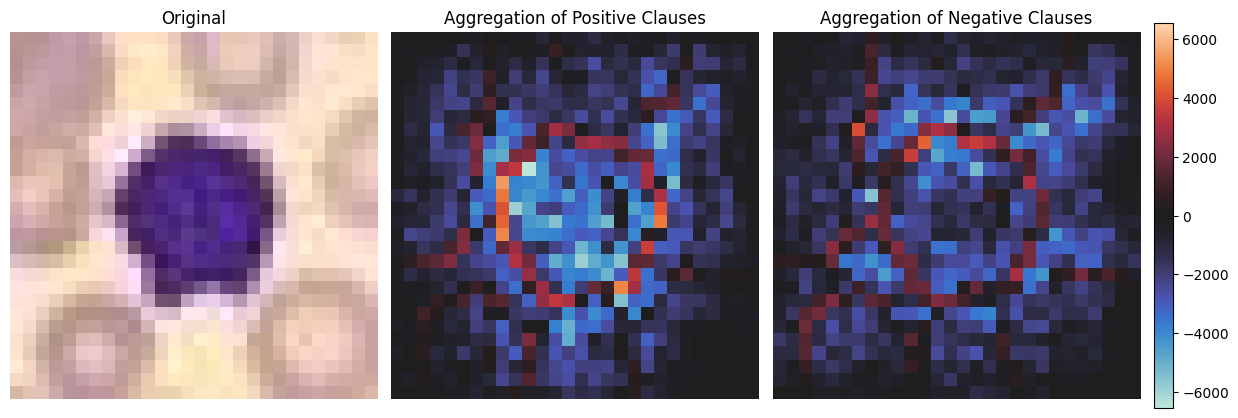

Visualizing sample 2046  |  predicted class: 4
2026-04-10 15:47:14,876 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6ae6a50>
2026-04-10 15:47:14,903 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9c3d8b0>
2026-04-10 15:47:14,930 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9fd5ee0>
Saved to saved_heatmaps/canny/blood_canny_lh_c4_s2046_chan.svg


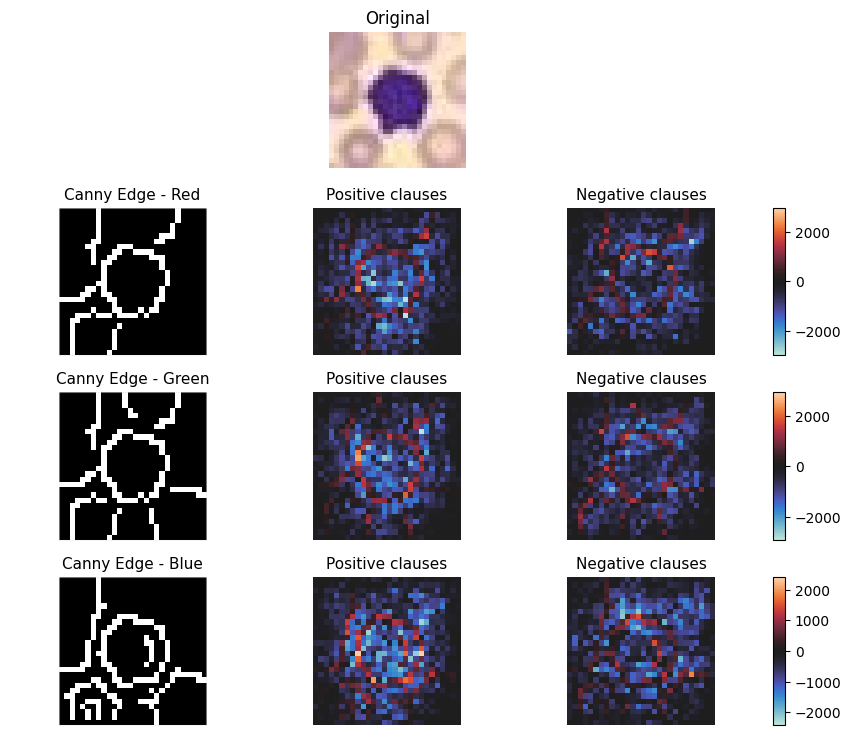

In [ ]:
image_index =  2046
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

4
Visualizing sample 1858  |  predicted class: 4
2026-04-10 15:47:18,751 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0dc2c90>
Saved to saved_heatmaps/canny/blood_canny_lh_c4_s1858_aggr.svg


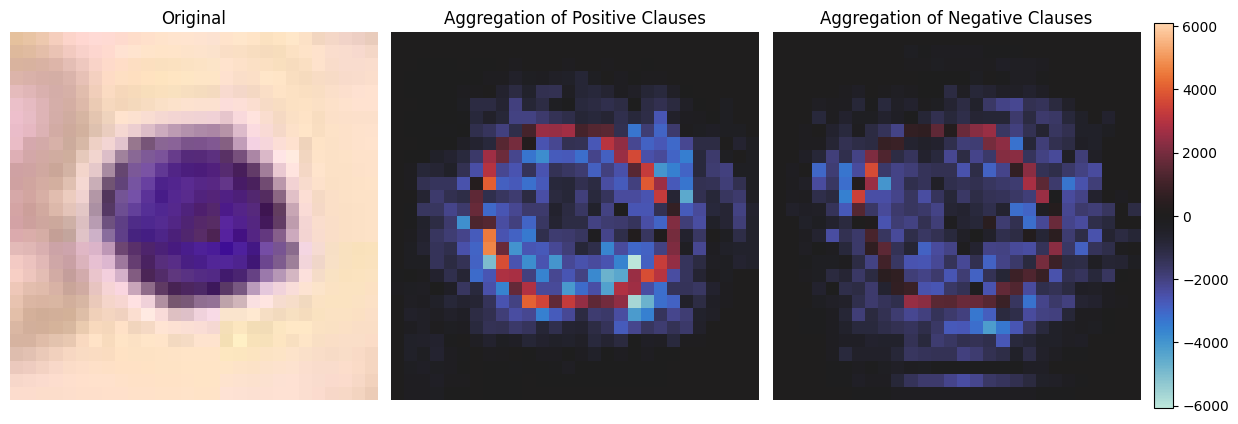

Visualizing sample 1858  |  predicted class: 4
2026-04-10 15:47:22,525 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac418a150>
2026-04-10 15:47:22,579 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0cbdd90>
2026-04-10 15:47:22,608 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0e60d10>
Saved to saved_heatmaps/canny/blood_canny_lh_c4_s1858_chan.svg


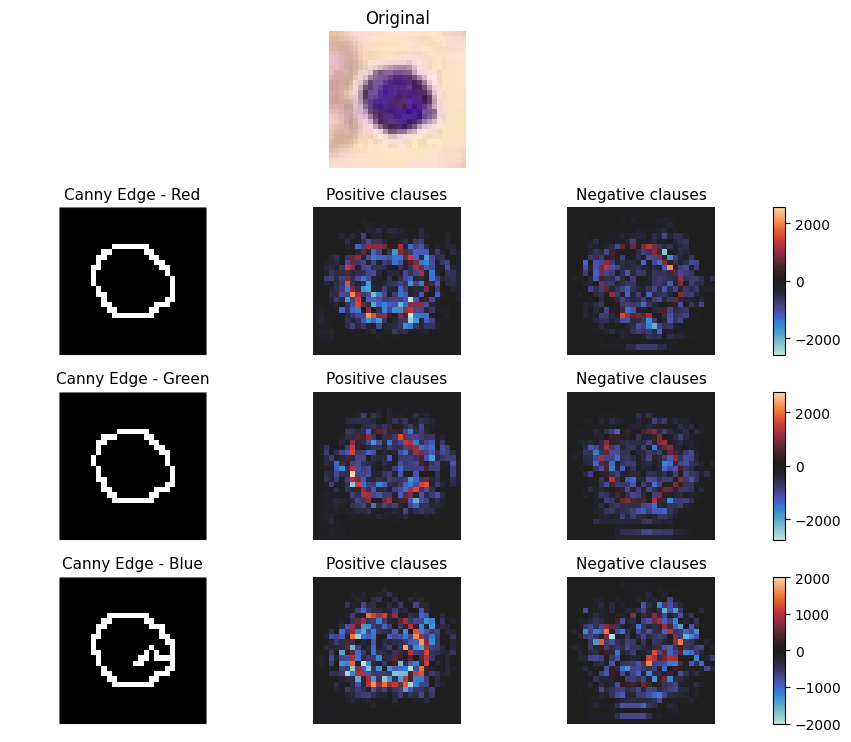

In [ ]:
image_index =  1858
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 5 Local Examples

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=5, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

5
Visualizing sample 1710  |  predicted class: 5
2026-04-10 15:47:27,224 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac4173650>
Saved to saved_heatmaps/canny/blood_canny_lh_c5_s1710_aggr.svg


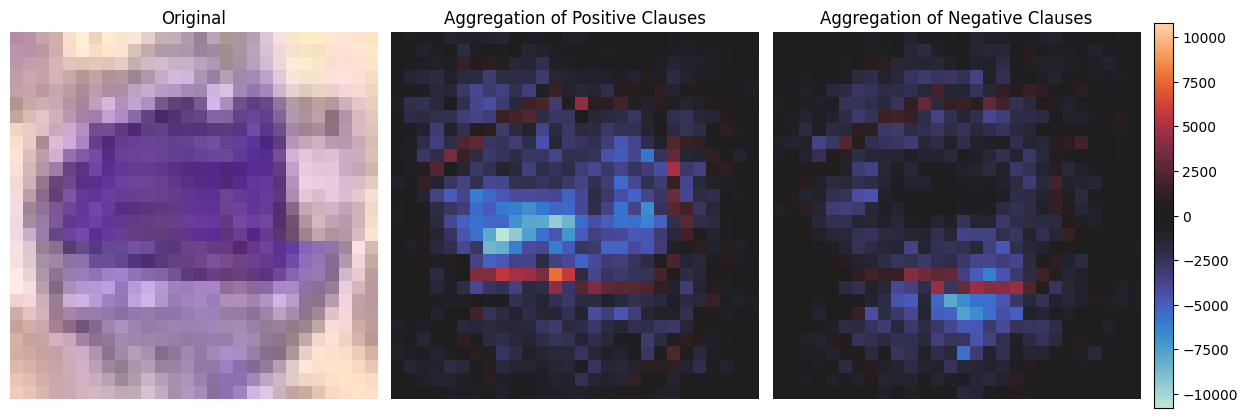

Visualizing sample 1710  |  predicted class: 5
2026-04-10 15:47:31,191 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0f37590>
2026-04-10 15:47:31,217 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9b59700>
2026-04-10 15:47:31,244 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0f344d0>
Saved to saved_heatmaps/canny/blood_canny_lh_c5_s1710_chan.svg


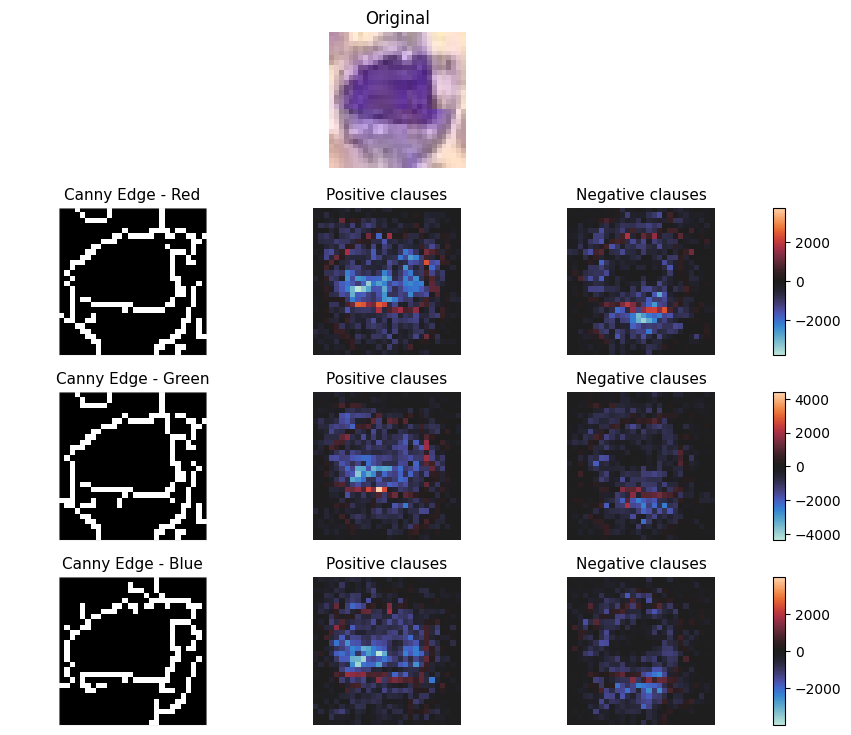

In [ ]:
image_index =  1710
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

5
Visualizing sample 1599  |  predicted class: 5
2026-04-10 15:47:35,665 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0eb6030>
Saved to saved_heatmaps/canny/blood_canny_lh_c5_s1599_aggr.svg


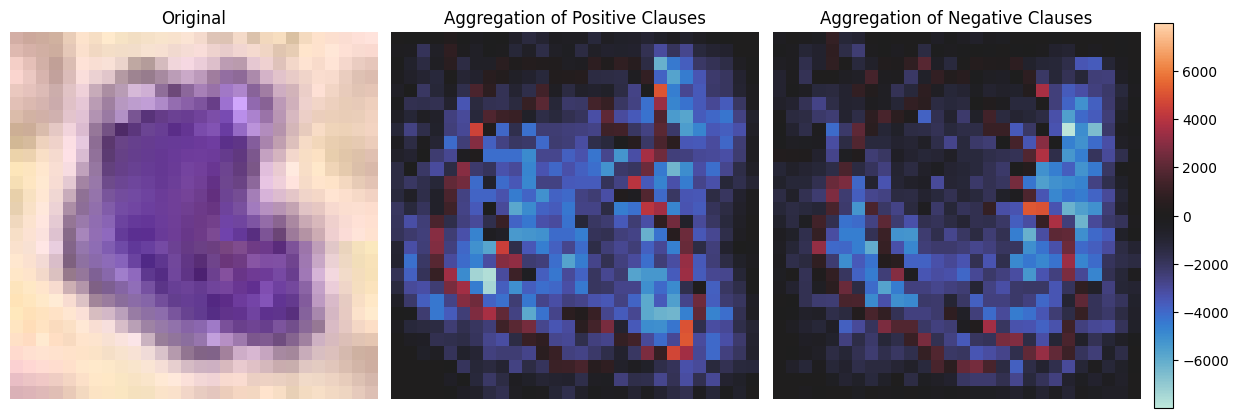

Visualizing sample 1599  |  predicted class: 5
2026-04-10 15:47:40,106 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0e269c0>
2026-04-10 15:47:40,134 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9abd700>
2026-04-10 15:47:40,160 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca130680>
Saved to saved_heatmaps/canny/blood_canny_lh_c5_s1599_chan.svg


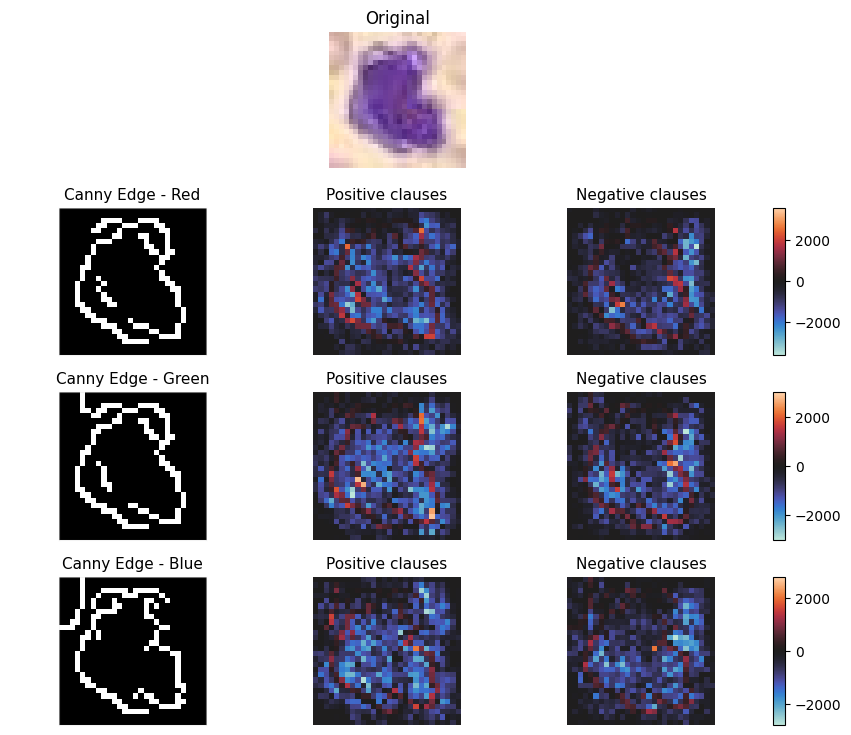

In [ ]:
image_index =  1599
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

5


Visualizing sample 2494  |  predicted class: 5
2026-04-10 15:47:44,272 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9b0c0e0>
Saved to saved_heatmaps/canny/blood_canny_lh_c5_s2494_aggr.svg


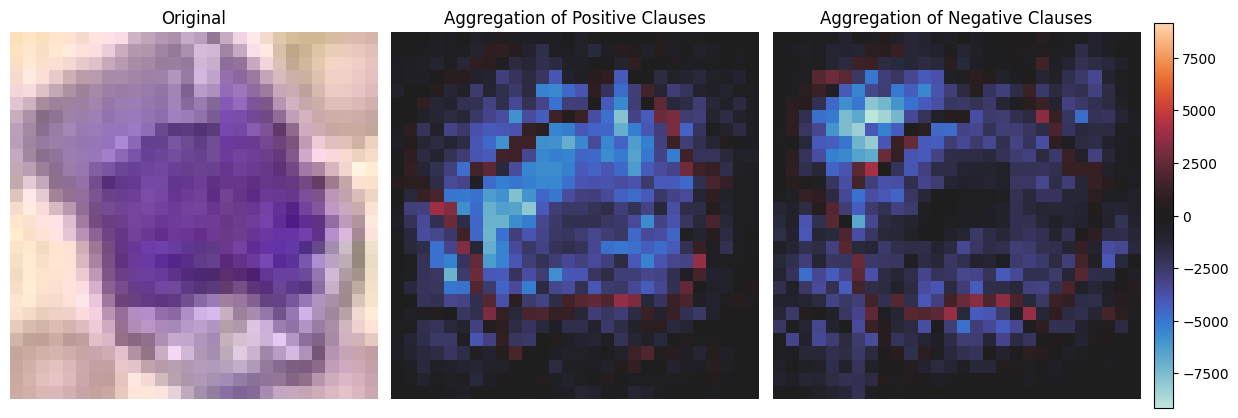

Visualizing sample 2494  |  predicted class: 5
2026-04-10 15:47:48,286 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0eaf4a0>
2026-04-10 15:47:48,312 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca011d60>
2026-04-10 15:47:48,342 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ad066b8c0>
Saved to saved_heatmaps/canny/blood_canny_lh_c5_s2494_chan.svg


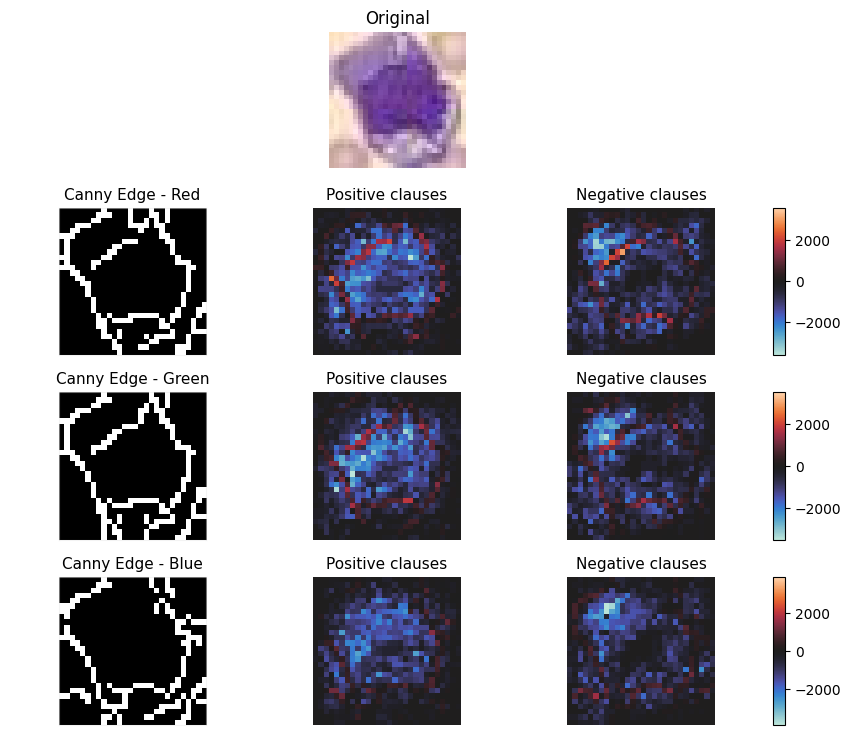

In [ ]:
image_index =  2494
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 6 Local Examples

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=6, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

6
Visualizing sample 151  |  predicted class: 6
2026-04-10 15:47:52,810 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ad05f3140>
Saved to saved_heatmaps/canny/blood_canny_lh_c6_s151_aggr.svg


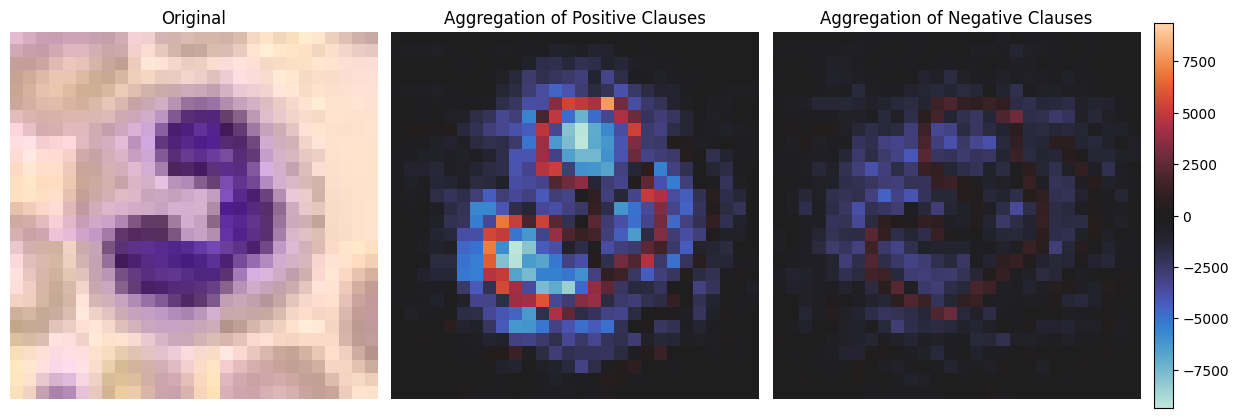

Visualizing sample 151  |  predicted class: 6
2026-04-10 15:47:56,960 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ad060b080>
2026-04-10 15:47:56,988 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9c55a30>
2026-04-10 15:47:57,016 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9d06b70>
Saved to saved_heatmaps/canny/blood_canny_lh_c6_s151_chan.svg


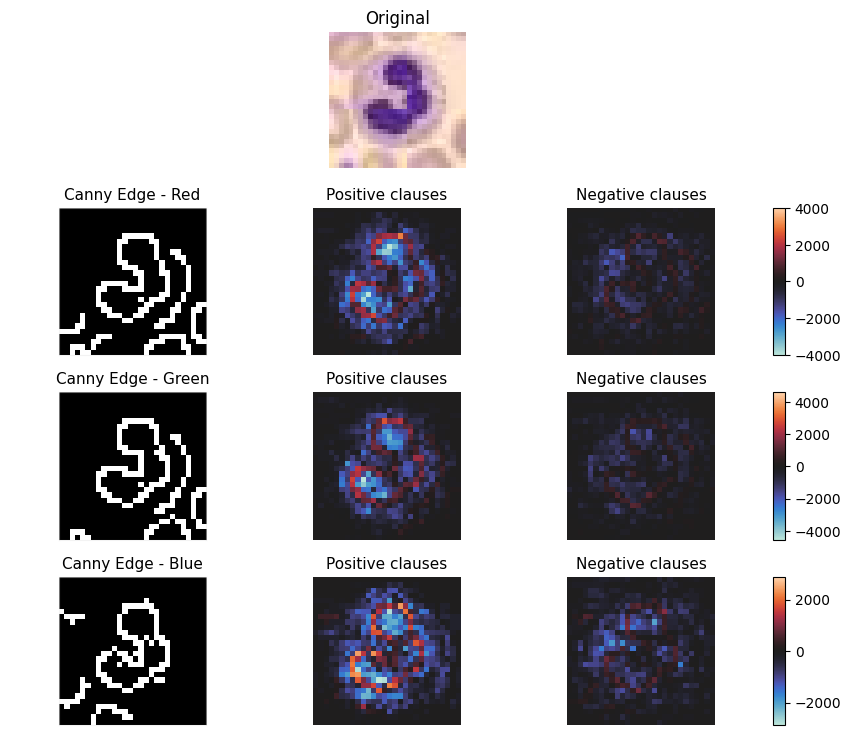

In [ ]:
image_index =  151
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

6
Visualizing sample 889  |  predicted class: 6
2026-04-10 15:48:01,030 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9cd8b90>
Saved to saved_heatmaps/canny/blood_canny_lh_c6_s889_aggr.svg


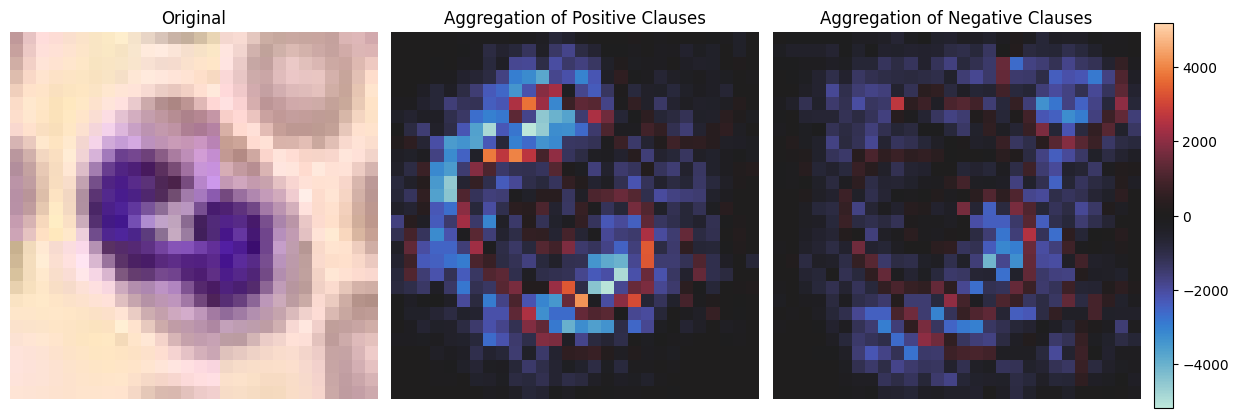

Visualizing sample 889  |  predicted class: 6
2026-04-10 15:48:04,783 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0ee9910>
2026-04-10 15:48:04,951 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ad06c0e60>
2026-04-10 15:48:04,979 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca123f50>
Saved to saved_heatmaps/canny/blood_canny_lh_c6_s889_chan.svg


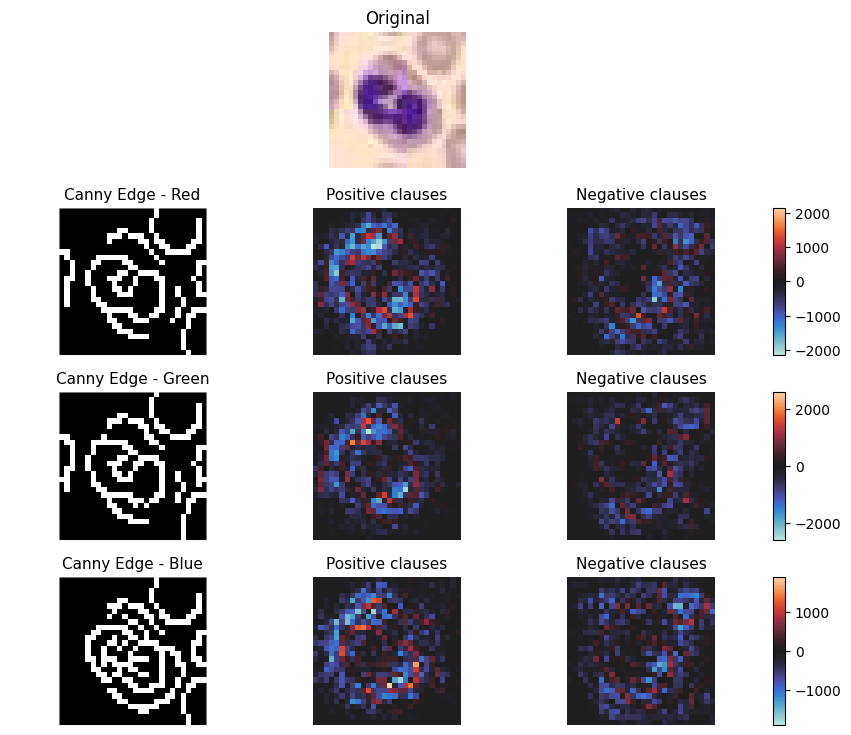

In [ ]:
image_index =  889
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

6
Visualizing sample 2517  |  predicted class: 6
2026-04-10 15:48:09,121 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca0d2f90>
Saved to saved_heatmaps/canny/blood_canny_lh_c6_s2517_aggr.svg


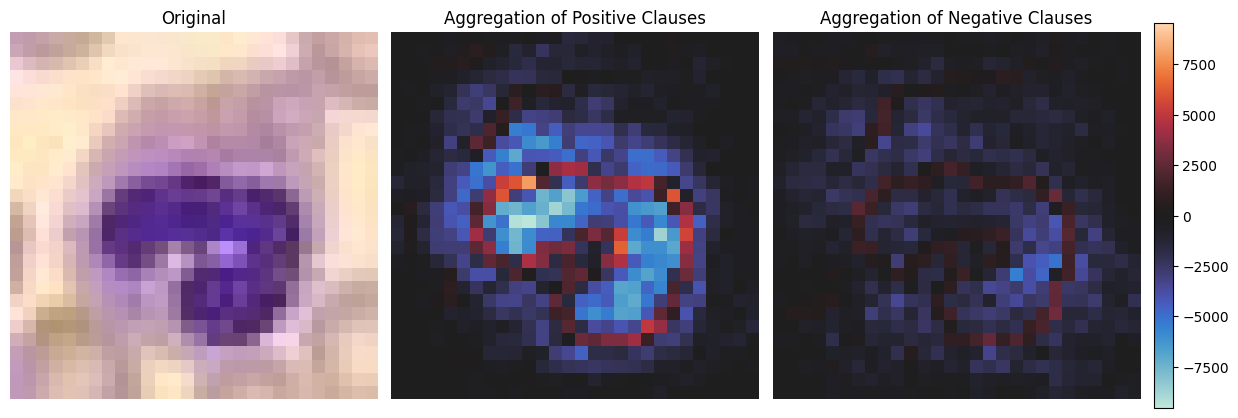

Visualizing sample 2517  |  predicted class: 6
2026-04-10 15:48:13,245 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac41a30b0>
2026-04-10 15:48:13,274 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac4111130>
2026-04-10 15:48:13,303 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac41d0620>
Saved to saved_heatmaps/canny/blood_canny_lh_c6_s2517_chan.svg


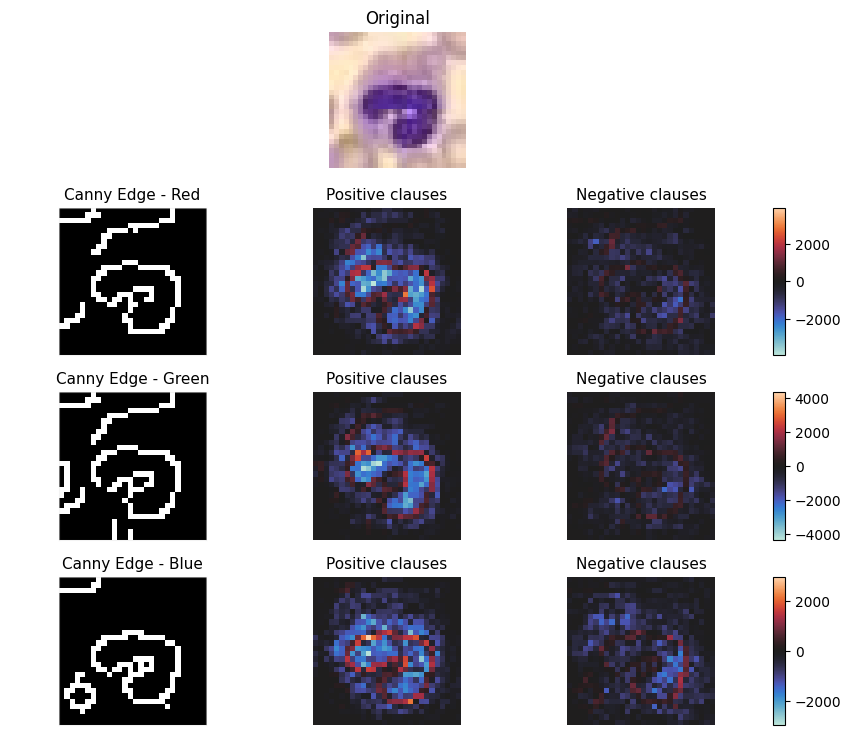

In [ ]:
image_index =  2517
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 7 Local Examples

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=7, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

7
Visualizing sample 2138  |  predicted class: 7
2026-04-10 15:48:17,729 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0ce8ec0>
Saved to saved_heatmaps/canny/blood_canny_lh_c7_s2138_aggr.svg


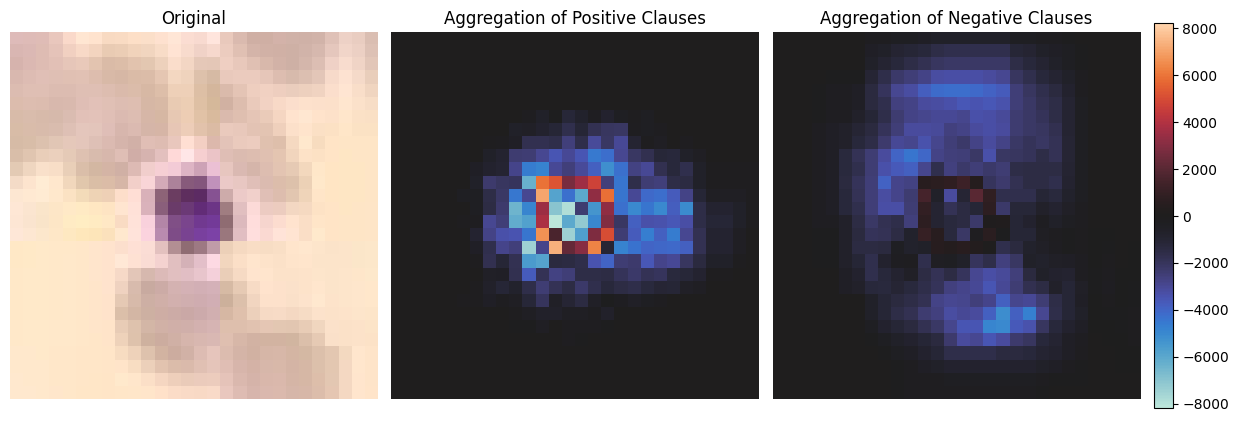

Visualizing sample 2138  |  predicted class: 7
2026-04-10 15:48:21,311 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0eaef30>
2026-04-10 15:48:21,340 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791aca0e8710>
2026-04-10 15:48:21,498 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9fd59d0>
Saved to saved_heatmaps/canny/blood_canny_lh_c7_s2138_chan.svg


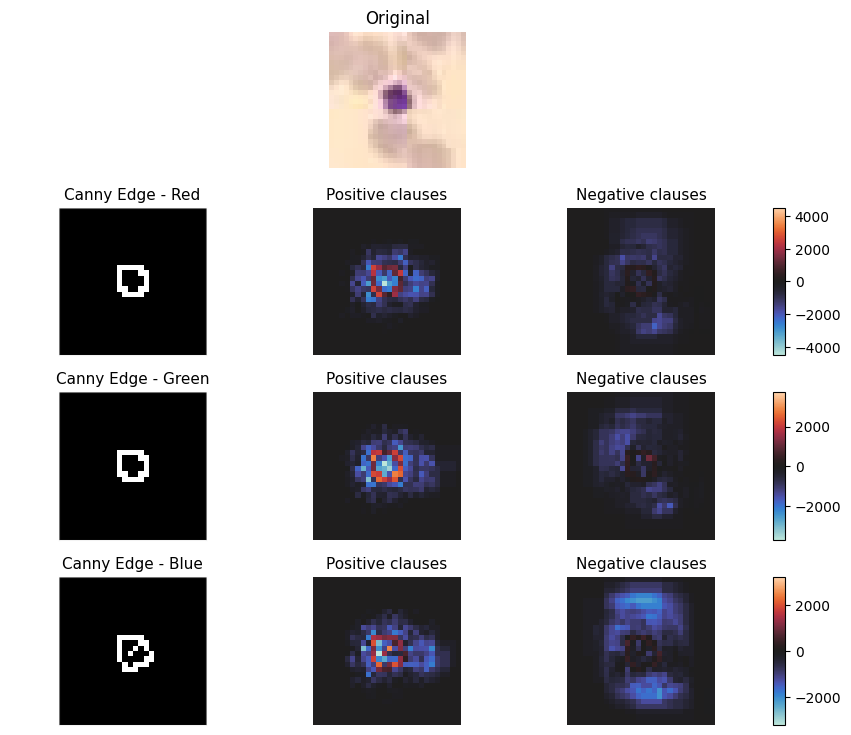

In [ ]:
image_index =  2138
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

7
Visualizing sample 1190  |  predicted class: 7
2026-04-10 15:48:26,171 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0d27110>
Saved to saved_heatmaps/canny/blood_canny_lh_c7_s1190_aggr.svg


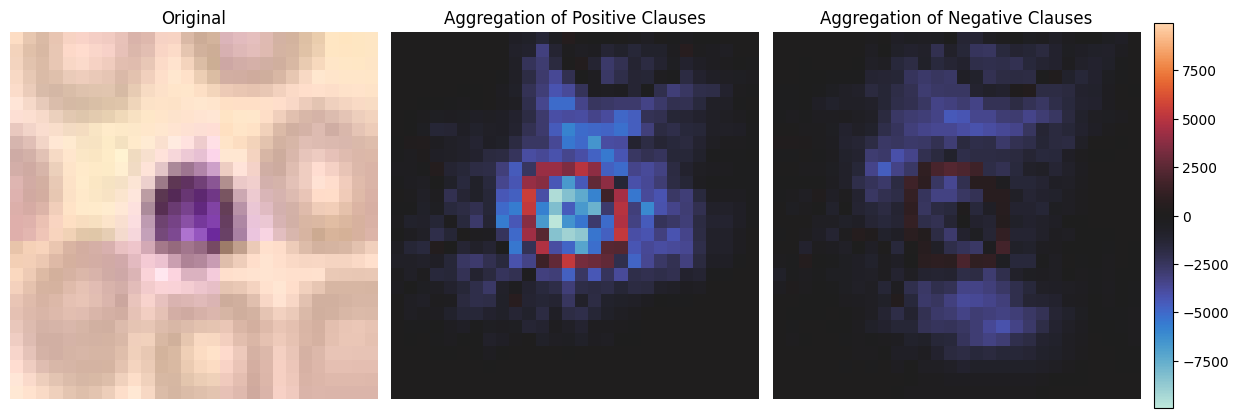

Visualizing sample 1190  |  predicted class: 7
2026-04-10 15:48:30,593 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6b1b860>
2026-04-10 15:48:30,621 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9c662d0>
2026-04-10 15:48:30,648 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9e0c680>
Saved to saved_heatmaps/canny/blood_canny_lh_c7_s1190_chan.svg


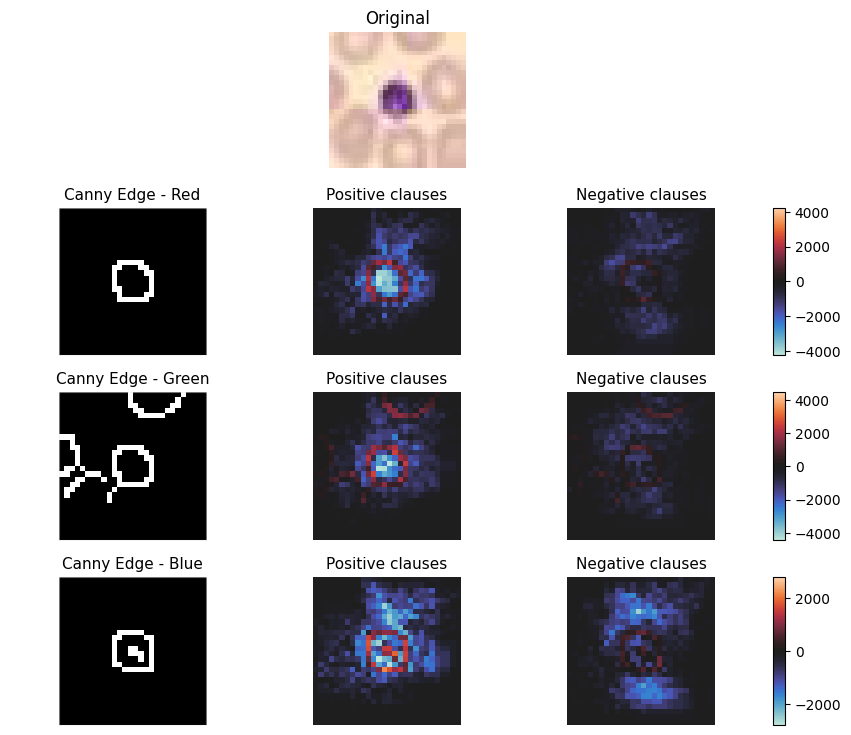

In [ ]:
image_index =  1190
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

7


Visualizing sample 1878  |  predicted class: 7
2026-04-10 15:48:35,041 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6afd490>
Saved to saved_heatmaps/canny/blood_canny_lh_c7_s1878_aggr.svg


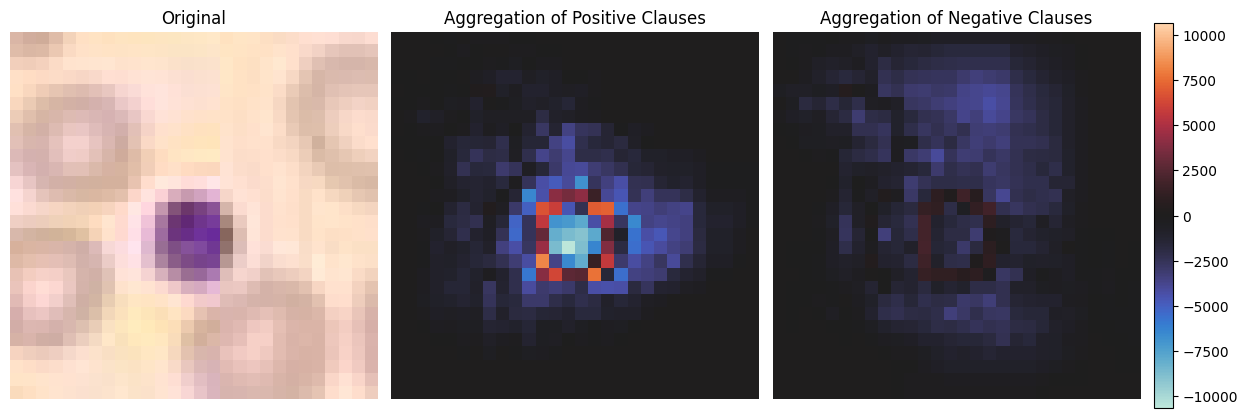

Visualizing sample 1878  |  predicted class: 7
2026-04-10 15:48:39,161 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ad06c2b70>
2026-04-10 15:48:39,189 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9ca3d10>
2026-04-10 15:48:39,365 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0d3e390>
Saved to saved_heatmaps/canny/blood_canny_lh_c7_s1878_chan.svg


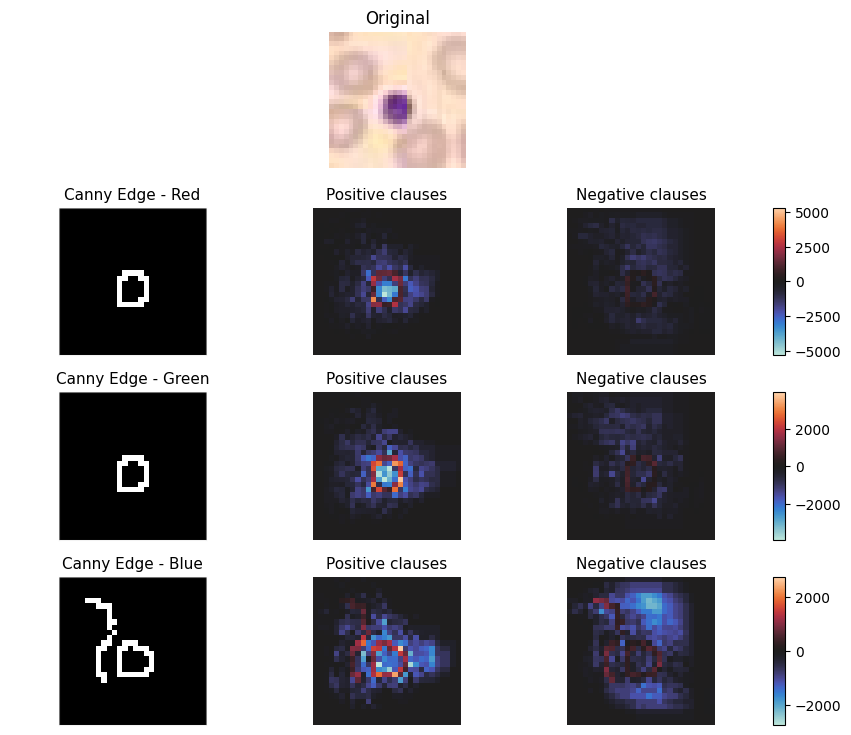

In [ ]:
image_index =  1878
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Global Heatmap 0

In [ ]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 0

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 15:48:40,083 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0dc3320>


Saved to saved_heatmaps/canny/blood_canny_gh_c0.svg


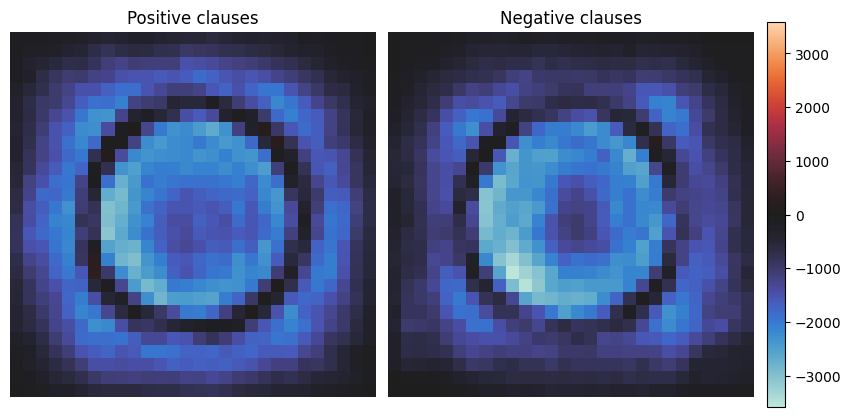

pos shape: (28, 28), min: -3106.34, max: 330.56
neg shape: (28, 28), min: -3586.54, max: 193.35
saved_heatmaps/canny/blood_canny_gh_c0.svg


In [ ]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 1

In [ ]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 1

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 15:48:40,489 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9abfef0>
Saved to saved_heatmaps/canny/blood_canny_gh_c1.svg


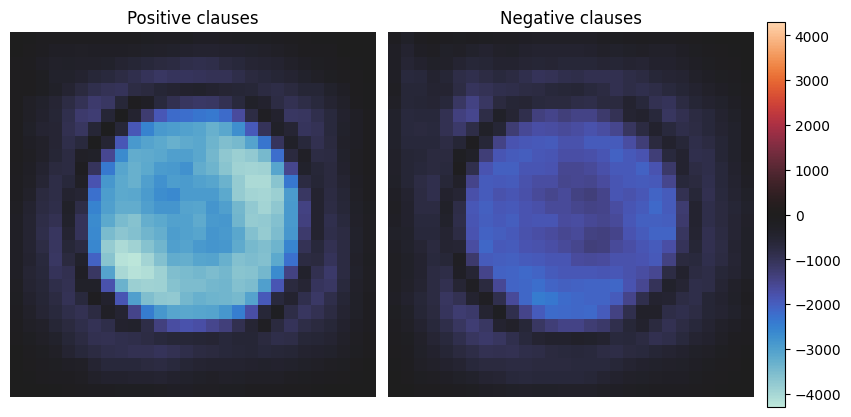

pos shape: (28, 28), min: -4298.41, max: -14.26
neg shape: (28, 28), min: -2436.17, max: -22.79
saved_heatmaps/canny/blood_canny_gh_c1.svg


In [ ]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 2

In [ ]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 2

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 15:48:40,856 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0f343b0>


Saved to saved_heatmaps/canny/blood_canny_gh_c2.svg


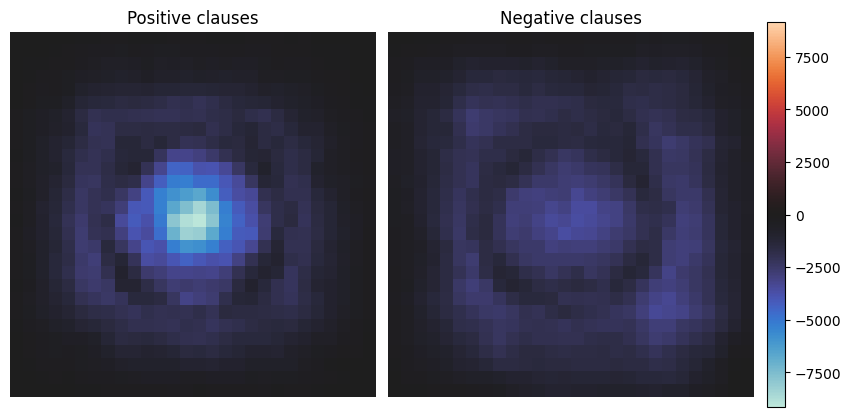

pos shape: (28, 28), min: -9152.15, max: -23.75
neg shape: (28, 28), min: -3625.56, max: -32.29
saved_heatmaps/canny/blood_canny_gh_c2.svg


In [ ]:
target_class = 2
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 3

In [ ]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 3

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 15:48:41,220 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9f944a0>
Saved to saved_heatmaps/canny/blood_canny_gh_c3.svg


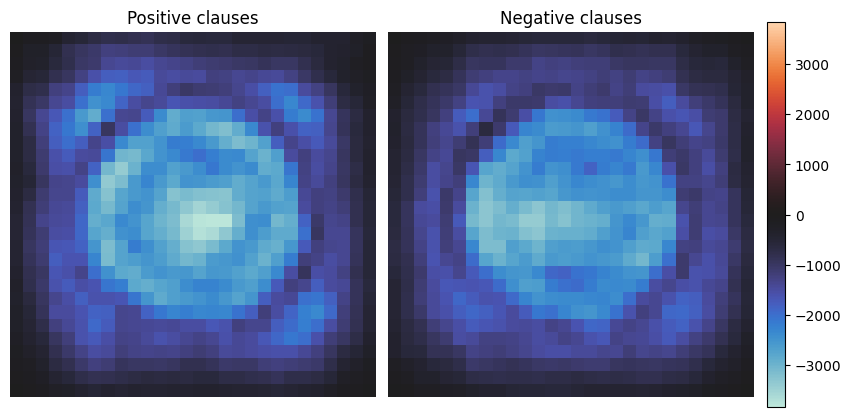

pos shape: (28, 28), min: -3836.17, max: -49.15
neg shape: (28, 28), min: -3409.42, max: -56.80
saved_heatmaps/canny/blood_canny_gh_c3.svg


In [ ]:
target_class = 3
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 4

In [ ]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 4

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 15:48:41,581 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac0e27620>


Saved to saved_heatmaps/canny/blood_canny_gh_c4.svg


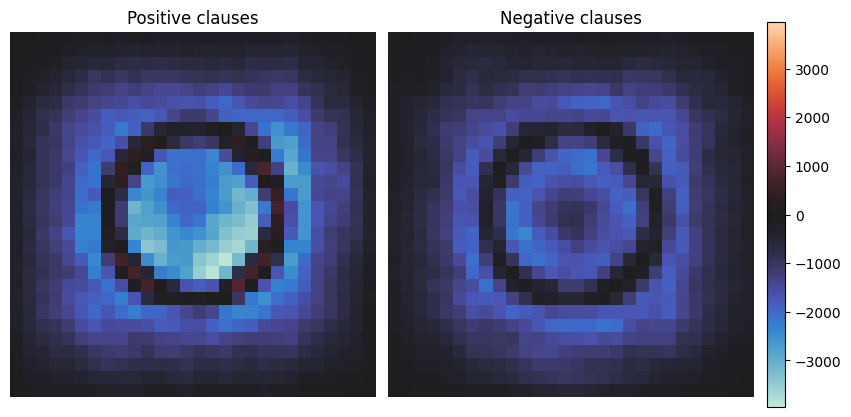

pos shape: (28, 28), min: -3956.40, max: 888.43
neg shape: (28, 28), min: -2386.11, max: 68.38
saved_heatmaps/canny/blood_canny_gh_c4.svg


In [ ]:
target_class = 4
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 5

In [ ]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 5

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 15:48:41,937 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9be8530>


Saved to saved_heatmaps/canny/blood_canny_gh_c5.svg


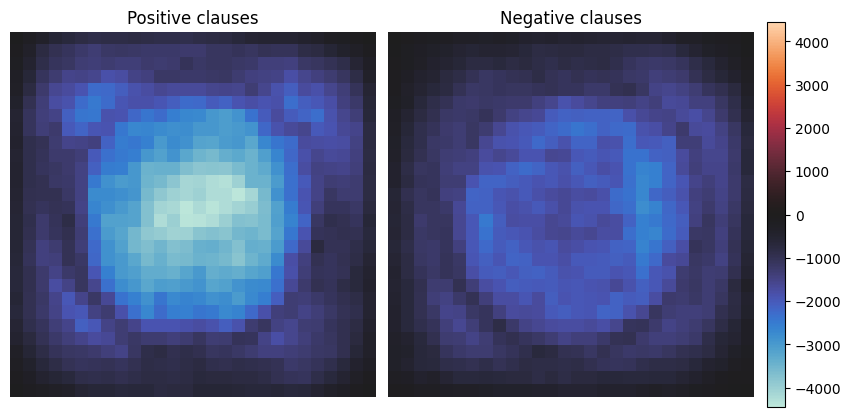

pos shape: (28, 28), min: -4447.70, max: -59.68
neg shape: (28, 28), min: -2801.37, max: -32.87
saved_heatmaps/canny/blood_canny_gh_c5.svg


In [ ]:
target_class = 5
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 6

In [ ]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 6

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 15:48:42,334 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac6b32d20>
Saved to saved_heatmaps/canny/blood_canny_gh_c6.svg


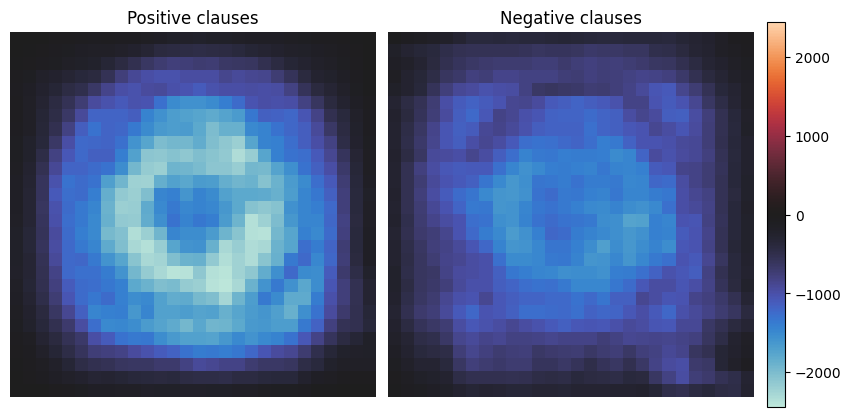

pos shape: (28, 28), min: -2440.92, max: -9.17
neg shape: (28, 28), min: -1738.56, max: -40.03
saved_heatmaps/canny/blood_canny_gh_c6.svg


In [ ]:
target_class = 6
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 7 

In [ ]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 7

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 15:48:42,678 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791ac9de2030>
Saved to saved_heatmaps/canny/blood_canny_gh_c7.svg


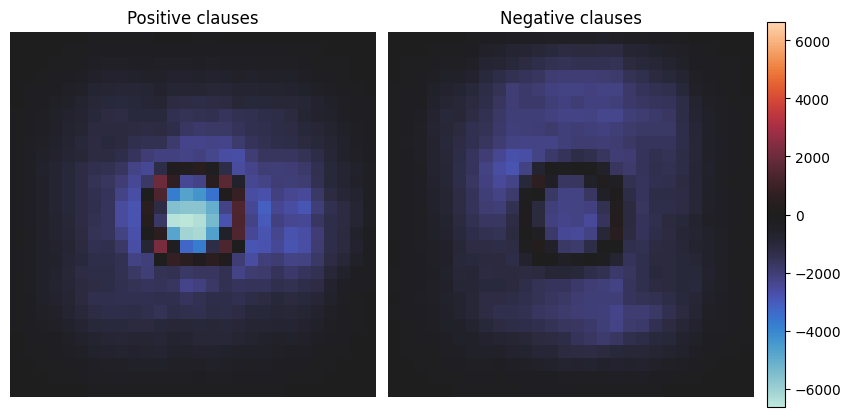

pos shape: (28, 28), min: -6635.96, max: 2217.58
neg shape: (28, 28), min: -2828.10, max: 572.49
saved_heatmaps/canny/blood_canny_gh_c7.svg


In [ ]:
target_class = 7
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)